# Importing packages

In [6]:
# Imports
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, MultipleLocator, FormatStrFormatter, ScalarFormatter, FuncFormatter

import geopandas as gpd
import cartopy.io.shapereader as shpreader
import regionmask

import cartopy.crs as ccrs
import dask
from pathlib import Path
import sys
from importlib import reload

# Custom libraries
PROJECT_ROOT = Path.home() / 'KNMIproject'
sys.path.insert(0, str(PROJECT_ROOT))

from RegionalTrends.Helpers import ProcessVar
reload(ProcessVar)
from RegionalTrends.Helpers.ProcessVar import load_var

from RegionalTrends.Helpers import AreaWeights
reload(AreaWeights)
from RegionalTrends.Helpers.AreaWeights import area_weights, area_weighted_mean

import RegionalTrends.Helpers.Config.Constants as Constants
reload(Constants)

plt.rcParams['axes.unicode_minus'] = False
dask.config.set(scheduler='threads', num_workers=12)

## Data loading

In [7]:
# User inputs
tends_main = {
    'Total': 'tendtot',
    'Diabatic': 'phystot',
    'Dynamic': 'dyntot',
    'Sensible': 'senstot',
    'Radiative': 'radtot',

    'SW all-sky directional': 'swnet',
    'LW all-sky directional': 'lwnet',

    'SW clear-cloud': 'swnet',
    'LW clear-cloud': 'lwnet',

    'SW clear-sky directional': 'scnet',
    'LW clear-sky directional': 'lcnet',

    'SW cloud directional': 'swcld',
    'LW cloud directional': 'lwcld',
}
tends_close = {
    'Total': ['dyntot', 'phystot', 'numtot'],
    'Diabatic': ['radtot', 'senstot', 'frictot'],
    'Dynamic': ['udtdx', 'vdtdy', 'adiadj', 'vertadv'],
    'Sensible': ['vdfsens', 'consens'],
    'Radiative': ['swnet', 'lwnet'],

    'SW all-sky directional': ['swtopdn', 'swtopup', 'swbotdn', 'swbotup'],
    'LW all-sky directional': ['lwtopdn', 'lwtopup', 'lwbotdn', 'lwbotup'],

    'SW clear-cloud': ['scnet', 'swcld'],
    'LW clear-cloud': ['lcnet', 'lwcld'],

    'SW clear-sky directional': ['sctopdn', 'sctopup', 'scbotdn', 'scbotup'],
    'LW clear-sky directional': ['lctopdn', 'lctopup', 'lcbotdn', 'lcbotup'],

    'SW cloud directional': ['swtopdncld', 'swtopupcld', 'swbotdncld', 'swbotupcld'],
    'LW cloud directional': ['lwtopdncld', 'lwtopupcld', 'lwbotdncld', 'lwbotupcld'],
}
t2m_datasets = ['RACMO2.4A', 'RACMO2.4R', 'ERA5', 'Eobs', 'Stations']
stations = ['Bilt', 'Eelde', 'Kooy', 'Maastricht', 'Vlissingen']
years = [1960, 2024]
file_freq = 'Daily'

lats = [50.7, 53.6]
lons = [3.25, 7.35]
proj_sel = 'RACMO2.4'
land_only = True
trim_border = None
shapefile_NL = True
use_nl_area_cache = True


In [8]:
# Config setup
data_sources = Constants.DATA_SOURCES
station_sources = Constants.STATION_SOURCES
station_coord_cfg = Constants.STATION_COORD_CFG
var_file_cfg = Constants.VAR_FILE_CFG
proj_cfg = Constants.PROJ_CFG

build_file_cfg_base = ProcessVar.build_file_cfg

def build_file_cfg_A(freq_str):
    freq_suffix = {'Daily': 'dailyA', 'Monthly': 'monthlyA', 'Seasonal': 'seasonalA'}[freq_str]
    cfg = build_file_cfg_base(freq_str)
    for var in Constants.ENBUD_VARS:
        cfg['RACMO2.4A'][var] = f'/nobackup_1/users/walj/racmo24/{freq_str}/{var}_{freq_suffix}_KEXT12_RACMO24p1v7_FINAL_enbud_fix_*.nc'
    return cfg

ProcessVar.build_file_cfg = build_file_cfg_A

In [ ]:
# Data loading
proj_sel = proj_cfg.get(proj_sel, ccrs.PlateCarree())
years_load = list(range(years[0], years[1] + 1))

import hashlib

nl_area_dir = Path('/nobackup_1/users/walj/racmo24/NL_area')
if use_nl_area_cache:
    nl_area_dir.mkdir(parents=True, exist_ok=True)


def nl_area_cache_path(dataset, var):
    cache_info = repr({
        'dataset': dataset,
        'var': var,
        'years': years,
        'file_freq': file_freq,
        'lats': lats,
        'lons': lons,
        'land_only': land_only,
        'trim_border': trim_border,
        'shapefile_NL': shapefile_NL,
    })
    cache_key = hashlib.md5(cache_info.encode()).hexdigest()[:10]
    return nl_area_dir / f'{dataset}_{var}_{file_freq}_{years[0]}-{years[1]}_{cache_key}.nc'


def nl_area_cache_exists(dataset, var):
    return use_nl_area_cache and nl_area_cache_path(dataset, var).exists()

derived_tendencies = {
    'senstot': ('sum', 'consens', 'vdfsens'),
    'phasetot': ('sum', 'conphase', 'vdfphase', 'lscld'),
    'frictot': ('sum', 'confric', 'vdffric'),
    'numtot': ('sum', 'numbnd', 'numdif'),
    'adiadj': ('sum', 'orography', 'adicomp'),
    'swtop': ('sum', 'swtopdn', 'swtopup'),
    'swbot': ('sum', 'swbotdn', 'swbotup'),
    'lwtop': ('sum', 'lwtopdn', 'lwtopup'),
    'lwbot': ('sum', 'lwbotdn', 'lwbotup'),
    'sctop': ('sum', 'sctopdn', 'sctopup'),
    'scbot': ('sum', 'scbotdn', 'scbotup'),
    'lctop': ('sum', 'lctopdn', 'lctopup'),
    'lcbot': ('sum', 'lcbotdn', 'lcbotup'),
    'swcld': ('diff', 'swnet', 'scnet'),
    'swnetcld': ('diff', 'swnet', 'scnet'),
    'lwcld': ('diff', 'lwnet', 'lcnet'),
    'swtopdncld': ('diff', 'swtopdn', 'sctopdn'),
    'swtopupcld': ('diff', 'swtopup', 'sctopup'),
    'swbotdncld': ('diff', 'swbotdn', 'scbotdn'),
    'swbotupcld': ('diff', 'swbotup', 'scbotup'),
    'lwtopdncld': ('diff', 'lwtopdn', 'lctopdn'),
    'lwtopupcld': ('diff', 'lwtopup', 'lctopup'),
    'lwbotdncld': ('diff', 'lwbotdn', 'lcbotdn'),
    'lwbotupcld': ('diff', 'lwbotup', 'lcbotup'),
}


def base_tendency_vars(var):
    if var not in derived_tendencies:
        return [var]

    out = []
    for dep in derived_tendencies[var][1:]:
        out.extend(base_tendency_vars(dep))
    return out


tend_vars = list(tends_main.values())
for variables in tends_close.values():
    tend_vars.extend(variables)

tend_vars_requested = list(set(tend_vars))
tend_vars_to_load = sorted(set(var for tend_var in tend_vars_requested for var in base_tendency_vars(tend_var)))
tends_to_load = {'RACMO2.4A': tend_vars_to_load}

temps_to_load = {dataset: ['Tg'] for dataset in t2m_datasets}
temps_to_load['RACMO2.4A'].append('templ1')


tends_data = {}

for dataset, variables in tends_to_load.items():
    tends_data[dataset] = {}

    for var in variables:
        if nl_area_cache_exists(dataset, var):
            print(f'Area cache exists {dataset}: {var}')
            tends_data[dataset][var] = None
            continue

        print(f'Loading {dataset}: {var}')
        tends_data[dataset][var] = load_var(
            var=var,
            data_source=dataset,
            data_sources=data_sources,
            station_sources=station_sources,
            file_freq=file_freq,
            var_file_cfg=var_file_cfg,
            proj_cfg=proj_cfg,
            months=None,
            years=years_load,
            lats=lats,
            lons=lons,
            land_only=land_only,
            trim_border=trim_border,
            rotpole_sel=proj_sel,
            station_coords=station_coord_cfg,
        )

temp_data = {}

for dataset, variables in temps_to_load.items():
    temp_data[dataset] = {}
    sources = stations if dataset == 'Stations' else [dataset]

    for var in variables:
        if nl_area_cache_exists(dataset, var):
            print(f'Area cache exists {dataset}: {var}')
            temp_data[dataset][var] = None
            continue

        loaded = []

        for source in sources:
            print(f'Loading {source}: {var}')
            is_station = source in station_sources
            loaded.append(load_var(
                var=var,
                data_source=source,
                data_sources=data_sources,
                station_sources=station_sources,
                file_freq=file_freq,
                var_file_cfg=var_file_cfg,
                proj_cfg=proj_cfg,
                months=None,
                years=years_load,
                lats=None if is_station else lats,
                lons=None if is_station else lons,
                land_only=False if is_station else land_only,
                trim_border=trim_border,
                rotpole_sel=proj_sel,
                station_coords=station_coord_cfg,
            ))

        if dataset == 'Stations':
            temp_data[dataset][var] = xr.concat(
                loaded,
                dim=pd.Index(stations, name='station'),
            ).mean('station', skipna=True)
        else:
            temp_data[dataset][var] = loaded[0]


Loading RACMO2.4A: swbotupcld
Loading RACMO2.4A: frictot
Loading RACMO2.4A: swbotdn
Loading RACMO2.4A: scbotdn
Loading RACMO2.4A: swnet
Loading RACMO2.4A: vertadv
Loading RACMO2.4A: phystot
Loading RACMO2.4A: lwcld
Loading RACMO2.4A: swbotup
Loading RACMO2.4A: lcnet
Loading RACMO2.4A: swcld
Loading RACMO2.4A: lcbotup
Loading RACMO2.4A: scnet
Loading RACMO2.4A: tendtot
Loading RACMO2.4A: numtot
Loading RACMO2.4A: lctopup
Loading RACMO2.4A: scbotup
Loading RACMO2.4A: swtopupcld
Loading RACMO2.4A: lwbotupcld
Loading RACMO2.4A: consens
Loading RACMO2.4A: sctopup
Loading RACMO2.4A: swbotdncld
Loading RACMO2.4A: swtopdn
Loading RACMO2.4A: swtopdncld
Loading RACMO2.4A: senstot
Loading RACMO2.4A: lcbotdn
Loading RACMO2.4A: swtopup
Loading RACMO2.4A: lwbotdn
Loading RACMO2.4A: lwbotup
Loading RACMO2.4A: lwtopup
Loading RACMO2.4A: radtot
Loading RACMO2.4A: dyntot
Loading RACMO2.4A: lwtopdn
Loading RACMO2.4A: udtdx
Loading RACMO2.4A: lwtopupcld
Loading RACMO2.4A: lwnet
Loading RACMO2.4A: adiadj
L

/usr/people/walj/KNMIproject/RegionalTrends/Helpers/ProcessNetCDF.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 338. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/usr/people/walj/KNMIproject/RegionalTrends/Helpers/ProcessNetCDF.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 242. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/usr/people/walj/KNMIproject/RegionalTrends/Helpers/ProcessNetCDF.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 409. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/usr/people/walj/KNMIproject/RegionalTrends/Helpers/ProcessNetCDF.py:18: UserWarning: The specified chunks separate the stored chunks along

Loading Eobs: Tg
Loading Bilt: Tg
Loading Eelde: Tg
Loading Kooy: Tg
Loading Maastricht: Tg
Loading Vlissingen: Tg


In [11]:
# Area Weighting
import hashlib

nl_area_dir = Path('/nobackup_1/users/walj/racmo24/NL_area')
if use_nl_area_cache:
    nl_area_dir.mkdir(parents=True, exist_ok=True)

nl_region = None
if shapefile_NL:
    countries = gpd.read_file(shpreader.natural_earth('10m', 'cultural', 'admin_0_countries'))
    nl_region = countries[countries['ADMIN'] == 'Netherlands'].to_crs('EPSG:4326')



def load_nl_area_cache(dataset, var):
    path = nl_area_cache_path(dataset, var)
    if use_nl_area_cache and path.exists():
        print(f'Loading cached area-weighted {dataset}: {var}')
        return xr.open_dataarray(path).load().astype('float32')
    return None


def save_nl_area_cache(da, dataset, var):
    if not use_nl_area_cache:
        return

    path = nl_area_cache_path(dataset, var)
    tmp_path = path.with_suffix('.tmp.nc')
    if tmp_path.exists():
        tmp_path.unlink()

    da = da.astype('float32')
    da.name = var
    da.to_netcdf(tmp_path)
    tmp_path.replace(path)


def area_mean_cached_method(dataset, da, weights):
    return area_weighted_mean(
        da,
        rotpole_native=proj_cfg.get(dataset, ccrs.PlateCarree()),
        weights=weights,
    ).compute().astype('float32')


def cached_area_mean(dataset, var, da, weights):
    cached = load_nl_area_cache(dataset, var)
    if cached is not None:
        return cached

    if da is None:
        raise FileNotFoundError(f'Area cache disappeared before loading {dataset}: {var}')

    print(f'Area-weighting {dataset}: {var}')
    out = area_mean_cached_method(dataset, da, weights)
    save_nl_area_cache(out, dataset, var)
    return out


def combine_area_var(var, area_data):
    if var in area_data:
        return area_data[var]

    op, *deps = derived_tendencies[var]
    parts = [combine_area_var(dep, area_data) for dep in deps]

    if op == 'sum':
        out = sum(parts[1:], parts[0])
    elif op == 'diff':
        out = parts[0] - parts[1]
    else:
        raise ValueError(f'Unknown derived operation: {op}')

    area_data[var] = out.astype('float32')
    return area_data[var]


weights_cache = {}
for dataset in set(tends_data) | set(temp_data):
    variables = tends_data.get(dataset) or temp_data.get(dataset)
    sample_data = next((da for da in variables.values() if da is not None), None)

    if sample_data is None:
        weights_cache[dataset] = None
        continue

    sample = sample_data.squeeze(drop=True)

    for dim in ['time', 'year', 'valid_time']:
        if dim in sample.dims:
            sample = sample.isel({dim: 0})

    print(f'Building weights: {dataset}')
    weights = area_weights(
        sample,
        rotpole_native=proj_cfg.get(dataset, ccrs.PlateCarree()),
    )

    if nl_region is not None and weights is not None and {'latitude', 'longitude'}.issubset(sample.coords):
        mask = regionmask.mask_geopandas(nl_region, sample['longitude'], sample['latitude']).notnull()
        weights = weights.where(mask)

    weights_cache[dataset] = weights.compute() if hasattr(weights, 'compute') else weights

tends_area = {}
for dataset, variables in tends_data.items():
    weights = weights_cache[dataset]
    area_data = {}

    for var, da in variables.items():
        area_data[var] = cached_area_mean(dataset, var, da, weights)

    for var in tend_vars_requested:
        tends_area[var] = combine_area_var(var, area_data)

temp_area = {}
for dataset, variables in temp_data.items():
    temp_area[dataset] = {}
    weights = weights_cache[dataset]

    for var, da in variables.items():
        temp_area[dataset][var] = cached_area_mean(dataset, var, da, weights)


Building weights: RACMO2.4R
Building weights: Stations
Building weights: ERA5
Building weights: Eobs
Building weights: RACMO2.4A
Area-weighting RACMO2.4A: swbotupcld
Area-weighting RACMO2.4A: frictot
Area-weighting RACMO2.4A: swbotdn


KeyboardInterrupt: 

## Processing tendencies

In [ ]:
# User inputs for processing
year_start_month = 12
rolling_window = 91
rolling_method = 'Triangular'
gaussian_sigma = rolling_window / 4


In [ ]:
# Processing
def rolling_weights(window):
    offsets = np.arange(-(window // 2), window // 2 + 1, dtype='float32')
    if rolling_method == 'Gaussian':
        weights = np.exp(-0.5 * (offsets / max(gaussian_sigma, 1.0))**2).astype('float32')
    elif rolling_method == 'Triangular':
        weights = (window // 2 + 1 - np.abs(offsets)).astype('float32')
    else:
        weights = np.ones(window, dtype='float32')
    return xr.DataArray(weights / weights.sum(), dims=('window',))

def smooth_time(da):

    window = min(int(rolling_window), da.sizes['time'])
    if window % 2 == 0:
        window = max(1, window - 1)

    if rolling_method == 'Boxcar':
        out = da.rolling(time=window, center=True, min_periods=window).mean().astype('float32')
        return out

    weights = rolling_weights(window)
    out = (
        da.rolling(time=window, center=True, min_periods=window)
        .construct('window')
        .dot(weights)
        .astype('float32')
    )
    return out

def to_noleap_temp(da):
    mask = ~((da['time'].dt.month == 2) & (da['time'].dt.day == 29))
    return da.where(mask, drop=True).astype('float32')

def to_noleap_tendency(da):
    feb29 = (da['time'].dt.month == 2) & (da['time'].dt.day == 29)
    time_nl = xr.where(feb29, da['time'] - np.timedelta64(1, 'D'), da['time'])
    out = (
        da.assign_coords(time_nl=('time', time_nl.data))
        .groupby('time_nl')
        .sum('time', skipna=True)
        .rename({'time_nl': 'time'})
        .sortby('time')
        .astype('float32')
    )
    return out

def analysis_year(da):
    year = da['time'].dt.year
    if year_start_month == 1:
        return year
    return year + (da['time'].dt.month >= year_start_month)

def month_day_axis(month_day_values):
    x = pd.to_datetime(['2000-' + month_day for month_day in month_day_values])
    if year_start_month == 1:
        return pd.DatetimeIndex(x)
    plot_year = np.where(x.month >= year_start_month, 2000, 2001)
    plot_dates = pd.to_datetime({
        'year': plot_year.astype(int),
        'month': x.month.astype(int),
        'day': x.day.astype(int),
    })
    return pd.DatetimeIndex(plot_dates)

def reorder_month_day(da):
    if 'month_day' not in da.dims or year_start_month == 1:
        return da
    x = month_day_axis(da['month_day'].values)
    return da.isel(month_day=np.argsort(x.values))

def select_period(da, period):
    years_period = range(period[0], period[1] + 1)
    return da.where(analysis_year(da).isin(years_period), drop=True).astype('float32')

def average_period(da, period):
    da_period = select_period(da, period)

    month_day = xr.DataArray(
        da_period['time'].dt.strftime('%m-%d').data,
        dims=('time',),
        coords={'time': da_period['time']},
        name='month_day',
    )
    out = (
        da_period.assign_coords(month_day=month_day)
        .groupby('month_day')
        .mean('time', skipna=True)
        .astype('float32')
    )
    return reorder_month_day(out)

In [ ]:
# Tendtot for other datasets
tendtot_area = {}

for dataset, variables in temp_area.items():
    tendtot_area[dataset] = {}

    for var, da in variables.items():
        print(f'Calculating temperature increment: {dataset}: {var}')

        tendtot_area[dataset][var] = (
            da.shift(time=-1) - da
        ).isel(time=slice(None, -1)).astype('float32')

# No-leap processing
noleap_tend = {}
for var, da in tends_area.items():
    print(f'No-leap tendency {var}')
    noleap_tend[var] = to_noleap_tendency(da)

noleap_temp = {}
for dataset, variables in temp_area.items():
    noleap_temp[dataset] = {}
    for var, da in variables.items():
        print(f'No-leap temp {dataset}')
        noleap_temp[dataset][var] = to_noleap_temp(da)

noleap_tendtot = {}
for dataset, variables in tendtot_area.items():
    noleap_tendtot[dataset] = {}
    for var, da in variables.items():
        print(f'No-leap tendtot {dataset}')
        noleap_tendtot[dataset][var] = to_noleap_tendency(da)

# Smoothing
smooth_tend = {}
for var, da in noleap_tend.items():
    print(f'Smoothing tendency {var}')
    smooth_tend[var] = smooth_time(da)

smooth_temp = {}
for dataset, variables in noleap_temp.items():
    smooth_temp[dataset] = {}
    for var, da in variables.items():
        print(f'Smoothing temp {dataset}')
        smooth_temp[dataset][var] = smooth_time(da)

smooth_tendtot = {}
for dataset, variables in noleap_tendtot.items():
    smooth_tendtot[dataset] = {}
    for var, da in variables.items():
        print(f'Smoothing tendtot {dataset}')
        smooth_tendtot[dataset][var] = smooth_time(da)

Calculating temperature increment: RACMO2.4A: Tg
Calculating temperature increment: RACMO2.4A: templ1
Calculating temperature increment: RACMO2.4R: Tg
Calculating temperature increment: ERA5: Tg
Calculating temperature increment: Eobs: Tg
Calculating temperature increment: Stations: Tg
No-leap tendency swbotdn
No-leap tendency lwnet
No-leap tendency swtopupcld
No-leap tendency lctopup
No-leap tendency vdfsens
No-leap tendency sctopdn
No-leap tendency swtopup
No-leap tendency radtot
No-leap tendency scbotup
No-leap tendency lwtopdncld
No-leap tendency swcld
No-leap tendency swbotupcld
No-leap tendency swtopdncld
No-leap tendency swnet
No-leap tendency adiadj
No-leap tendency senstot
No-leap tendency dyntot
No-leap tendency numtot
No-leap tendency vdtdy
No-leap tendency lwbotdncld
No-leap tendency swbotdncld
No-leap tendency scbotdn
No-leap tendency phystot
No-leap tendency lwbotupcld
No-leap tendency lctopdn
No-leap tendency vertadv
No-leap tendency lwtopdn
No-leap tendency lwtopup
No-l

In [ ]:
periods = {
    'Pref':  [1963, 1988],
    'PrefL': [1963, 1975],
    'PrefR': [1976, 1988],

    'Ptrend':  [1980, 2023],
    'PtrendL': [1980, 2001],
    'PtrendR': [2002, 2023],
}

In [ ]:
# Climatologies over periods
clim_tend = {}
for var, da in smooth_tend.items():
    print(f'Climatological tendency {var}')
    clim_tend[var] = {
        period_key: average_period(da, period)
        for period_key, period in periods.items()
    }

clim_temp = {}
for dataset, variables in smooth_temp.items():
    clim_temp[dataset] = {}
    for var, da in variables.items():
        print(f'Climatological temp {dataset}')
        clim_temp[dataset][var] = {
            period_key: average_period(da, period)
            for period_key, period in periods.items()
        }

clim_tendtot = {}
for dataset, variables in smooth_tendtot.items():
    clim_tendtot[dataset] = {}
    for var, da in variables.items():
        print(f'Climatological tendtot {dataset}')
        clim_tendtot[dataset][var] = {
            period_key: average_period(da, period)
            for period_key, period in periods.items()
        }

Climatological tendency swbotdn
Climatological tendency lwnet
Climatological tendency swtopupcld
Climatological tendency lctopup
Climatological tendency vdfsens
Climatological tendency sctopdn
Climatological tendency swtopup
Climatological tendency radtot
Climatological tendency scbotup
Climatological tendency lwtopdncld
Climatological tendency swcld
Climatological tendency swbotupcld
Climatological tendency swtopdncld
Climatological tendency swnet
Climatological tendency adiadj
Climatological tendency senstot
Climatological tendency dyntot
Climatological tendency numtot
Climatological tendency vdtdy
Climatological tendency lwbotdncld
Climatological tendency swbotdncld
Climatological tendency scbotdn
Climatological tendency phystot
Climatological tendency lwbotupcld
Climatological tendency lctopdn
Climatological tendency vertadv
Climatological tendency lwtopdn
Climatological tendency lwtopup
Climatological tendency lwtopupcld
Climatological tendency swbotup
Climatological tendency scto

## Annual offsets and shape

In [ ]:
def weights_kappa(period1, period2):
    y0_1, y1_1 = period1
    y0_2, y1_2 = period2

    n1 = y1_1 - y0_1 + 1
    n2 = y1_2 - y0_2 + 1

    years = np.arange(y0_1, y1_2, dtype=int)
    weights = np.empty(years.size, dtype='float32')

    mask_p1 = years <= y1_1
    mask_p2 = years >= y0_2

    weights[mask_p1] = (years[mask_p1] - y0_1 + 1) / n1
    weights[mask_p2] = (y1_2 - years[mask_p2]) / n2

    return xr.DataArray(weights, dims='year', coords={'year': years}, name='kappa')

def weights_alpha(month_day):
    n = len(month_day)
    values = (np.arange(n, dtype='float32') + 1.0) / n
    return xr.DataArray(values, dims='month_day', coords={'month_day': month_day}, name='alpha')

def weights_beta(month_day):
    n = len(month_day)
    values = (n - 1 - np.arange(n, dtype='float32')) / n
    return xr.DataArray(values, dims='month_day', coords={'month_day': month_day}, name='beta')

def to_year_monthday(da):
    year = xr.DataArray(analysis_year(da).data, dims='time', coords={'time': da['time']})
    month_day = xr.DataArray(da['time'].dt.strftime('%m-%d').data, dims='time', coords={'time': da['time']})

    out = (
        da.assign_coords(year=year, month_day=month_day)
          .set_index(time=['year', 'month_day'])
          .unstack('time')
          .transpose('year', 'month_day')
          .astype('float32')
    )
    return reorder_month_day(out)

def new_cumsum(da):
    return da.shift(month_day=1, fill_value=0).cumsum('month_day').astype('float32')

def aggregate_calendar(da, split='day', how='sum'):
    if split == 'day':
        return da.astype('float32')

    month = xr.DataArray(
        pd.Index(da['month_day'].values.astype(str)).str.slice(0, 2).astype(int),
        dims='month_day',
        coords={'month_day': da['month_day']},
        name='month',
    )

    if split == 'month':
        grouped = da.assign_coords(month=month).groupby('month')
        if how == 'mean':
            return grouped.mean('month_day', skipna=True).astype('float32')
        return grouped.sum('month_day', skipna=True).astype('float32')

    if split == 'season':
        season_labels = np.empty(month.size, dtype='<U3')
        season_labels[np.isin(month, [12, 1, 2])] = 'DJF'
        season_labels[np.isin(month, [3, 4, 5])] = 'MAM'
        season_labels[np.isin(month, [6, 7, 8])] = 'JJA'
        season_labels[np.isin(month, [9, 10, 11])] = 'SON'

        season = xr.DataArray(
            season_labels,
            dims='month_day',
            coords={'month_day': da['month_day']},
            name='season',
        )
        grouped = da.assign_coords(season=season).groupby('season')
        if how == 'mean':
            out = grouped.mean('month_day', skipna=True).astype('float32')
        else:
            out = grouped.sum('month_day', skipna=True).astype('float32')
        order = [s for s in ['DJF', 'MAM', 'JJA', 'SON'] if s in out['season'].values]
        return out.sel(season=order)

def determine_mu(A_time, period_left, period_right, split='day'):
    A_y_d = to_year_monthday(A_time)
    kappa = weights_kappa(period_left, period_right)
    alpha = weights_alpha(A_y_d['month_day'])
    beta = weights_beta(A_y_d['month_day'])

    A_start = A_y_d.sel(year=kappa['year'])
    A_end = A_y_d.sel(year=kappa['year'].values + 1).assign_coords(year=kappa['year'])

    B_y_d = (alpha*A_start + beta*A_end).astype('float32')
    mu_calendar = (kappa*B_y_d).sum('year').astype('float32')
    mu_split = aggregate_calendar(mu_calendar, split=split)

    return {
        'mu_total': mu_split.sum().astype('float32'),
        'mu_split': mu_split.astype('float32'),
    }

def determine_shape(A_left_clim, A_right_clim, split='day'):
    deltaA_daily = (A_right_clim - A_left_clim).astype('float32')
    deltaA = aggregate_calendar(deltaA_daily, split=split)
    cumsum_daily = new_cumsum(deltaA_daily)
    Theta_daily = (cumsum_daily - cumsum_daily.mean('month_day')).astype('float32')
    Theta = aggregate_calendar(Theta_daily, split=split, how='mean')

    return {
        'deltaA': deltaA,
        'Theta': Theta,
    }

In [ ]:
# Shape and offset for all tendencies
offset_periods = {
    'Pref': ('PrefL', 'PrefR'),
    'Ptrend': ('PtrendL', 'PtrendR'),
}
splits = ['day', 'season']

offset_L = {
    period_key: weights_kappa(periods[left_key], periods[right_key]).sum('year').astype('float32')
    for period_key, (left_key, right_key) in offset_periods.items()
}

def determine_offsets_and_shapes(smooth_vars, clim_vars):
    annual_offset = {}
    shape = {}

    for split in splits:
        annual_offset[split] = {}
        shape[split] = {}

        for period_key, (left_key, right_key) in offset_periods.items():
            annual_offset[split][period_key] = {}
            shape[split][period_key] = {}
            L = offset_L[period_key]

            for var, da in smooth_vars.items():
                mu = determine_mu(da, periods[left_key], periods[right_key], split=split)
                offset_total = mu['mu_total'].squeeze(drop=True)
                offset_split = mu['mu_split'].squeeze(drop=True)

                annual_offset[split][period_key][var] = {
                    'offset': {
                        'total': offset_total,
                        'split': offset_split,
                    },
                    'trend': {
                        'total': (offset_total / L).astype('float32').squeeze(drop=True),
                        'split': (offset_split / L).astype('float32').squeeze(drop=True),
                    },
                }

                var_shape = determine_shape(
                    clim_vars[var][left_key],
                    clim_vars[var][right_key],
                    split=split,
                )
                shape[split][period_key][var] = {
                    name: value.squeeze(drop=True)
                    for name, value in var_shape.items()
                }

    return annual_offset, shape

annual_offset_tend, shape_tend = determine_offsets_and_shapes(smooth_tend, clim_tend)

annual_offset_tendtot = {}
shape_tendtot = {}
for dataset in smooth_tendtot:
    annual_offset_tendtot[dataset], shape_tendtot[dataset] = determine_offsets_and_shapes(
        smooth_tendtot[dataset],
        clim_tendtot[dataset],
    )

## Reference Period

In [ ]:
# Reference choice
reference_mode = 'stationary'      # 'period' or 'stationary'
reference_period_key = 'Pref'  # used only when reference_mode == 'period'

stationary_period_key = 'Ptrend'
stationary_left, stationary_right = offset_periods[stationary_period_key]

In [ ]:
def stationary_eta(A_L, A_R):
    D_L = A_L.sum('month_day').astype('float32')
    D_R = A_R.sum('month_day').astype('float32')
    return (-D_L / (D_R - D_L)).astype('float32').squeeze(drop=True)


def stationary_ref(A_L, A_R, eta):
    return ((1.0 - eta)*A_L + eta*A_R).astype('float32').squeeze(drop=True)


stationary_eta_proc = None
if reference_mode == 'stationary':
    stationary_eta_proc = stationary_eta(
        clim_tend['tendtot'][stationary_left],
        clim_tend['tendtot'][stationary_right],
    )


def ref_tendency(var, split='day', total=False, dataset=None):
    key = 'total' if total else 'split'

    if reference_mode == 'period':
        if dataset is None:
            return annual_offset_tend[split][reference_period_key][var]['trend'][key]
        return annual_offset_tendtot[dataset][split][reference_period_key][var]['trend'][key]

    if dataset is None:
        out = stationary_ref(
            clim_tend[var][stationary_left],
            clim_tend[var][stationary_right],
            stationary_eta_proc,
        )
    else:
        eta = stationary_eta(
            clim_tendtot[dataset][var][stationary_left],
            clim_tendtot[dataset][var][stationary_right],
        )
        out = stationary_ref(
            clim_tendtot[dataset][var][stationary_left],
            clim_tendtot[dataset][var][stationary_right],
            eta,
        )

    if split == 'season':
        out = aggregate_calendar(out, split='season', how='sum')

    if total:
        dim = 'month_day' if split == 'day' else 'season'
        return out.sum(dim).astype('float32').squeeze(drop=True)

    return out.astype('float32')

# PLOTTING!!

In [ ]:
# Shared plotting helpers
COLORS = ['#000000', '#DB2525', '#0168DE', '#00A236', '#CA721B', '#7B2CBF', '#E91E8C', '#808080']
season_order = ['DJF', 'MAM', 'JJA', 'SON', 'ALL']
name_map = {'RACMO2.4A': 'R2.4A', 'RACMO2.4R': 'R2.4', 'Eobs': 'E-OBS'}
TEMP_SELECTED_SERIES = [
    ('RACMO2.4A', 'templ1', 'R2.4A layer'),
    ('RACMO2.4A', 'Tg', 'R2.4A'),
    ('RACMO2.4R', 'Tg', 'R2.4'),
    ('ERA5', 'Tg', 'ERA5'),
]


def available_temp_series(selected=None, all_tg=False, require=()):
    selected = selected or TEMP_SELECTED_SERIES
    if all_tg:
        selected = []
        if 'RACMO2.4A' in clim_temp and 'templ1' in clim_temp['RACMO2.4A']:
            selected.append(('RACMO2.4A', 'templ1', 'R2.4A layer'))
        selected += [(ds, 'Tg', name_map.get(ds, ds)) for ds in clim_temp if 'Tg' in clim_temp[ds]]

    series = []
    for i, (ds, var, label) in enumerate(selected):
        missing = [name for store, name in require if ds not in store or var not in store[ds]]
        if missing:
            print(f'Skipping {ds} {var}, not found in {", ".join(missing)}')
            continue
        series.append({
            'dataset': ds,
            'var': var,
            'label': label,
            'color': COLORS[i % len(COLORS)],
            'edgecolor': 'black',
            'linewidth': 0.8,
            'lw_temp': [3.8, 2.6, 2.0, 1.5][i] if i < 4 else max(1.3, 1.5 - 0.10 * (i - 3)),
            'lw_tend': [3.2, 2.3, 1.8, 1.35][i] if i < 4 else max(1.15, 1.35 - 0.08 * (i - 3)),
            'lw_cumulative': [3.4, 2.45, 2.10, 1.75][i] if i < 4 else 1.55,
            'lw_increment': [2.25, 1.85, 1.60, 1.35][i] if i < 4 else 1.20,
        })
    return series


def series_handles(series, kind='line', lw=2.4):
    if kind == 'patch':
        return [Patch(facecolor=s['color'], edgecolor=s.get('edgecolor', 'black'), linewidth=s.get('linewidth', 0.8), label=s['label']) for s in series]
    return [Line2D([0], [0], color=s['color'], lw=lw, label=s['label']) for s in series]


def month_tick_positions():
    return pd.date_range(pd.Timestamp(2000, year_start_month, 1), periods=12, freq='MS')


def period_label(period_key):
    return f'{periods[period_key][0]}-{periods[period_key][1]}'


def to_float(value):
    value = value.squeeze(drop=True)
    if hasattr(value.data, 'compute'):
        value = value.compute()
    return float(value.item())


def stack_values(values):
    chunks = [np.asarray(value, dtype=float).ravel() for value in values]
    chunks = [chunk[np.isfinite(chunk)] for chunk in chunks if chunk.size]
    return np.concatenate(chunks) if chunks else np.asarray([0.0])


def limits(values, pad=0.08, zero=False, symmetric=False):
    values = stack_values([values])
    if symmetric:
        limit = (1.0 + pad) * max(float(np.max(np.abs(values))), 1e-9)
        return -limit, limit

    vmin, vmax = float(values.min()), float(values.max())
    if zero:
        if vmin >= 0.0:
            return 0.0, vmax + pad * max(vmax, 1e-9)
        if vmax <= 0.0:
            return vmin - pad * max(abs(vmin), 1e-9), 0.0
        vmin, vmax = min(vmin, 0.0), max(vmax, 0.0)
    pad_value = pad * max(vmax - vmin, 1e-9)
    return vmin - pad_value, vmax + pad_value


def clean_1d(da, dim):
    da = da.squeeze(drop=True).astype('float32')
    extra_dims = [d for d in da.dims if d != dim]
    if extra_dims:
        raise ValueError(f'Expected only {dim}, found {extra_dims}')
    return da.transpose(dim)


def tendency_split(ds, var, period_key, split='day', seasons=('DJF', 'MAM', 'JJA', 'SON')):
    dim = 'month_day' if split == 'day' else 'season'
    da = clean_1d(annual_offset_tendtot[ds][split][period_key][var]['trend']['split'], dim)
    return da.sel(season=list(seasons)) if split == 'season' else da

def season_plus_all(season_da, all_value, seasons=('DJF', 'MAM', 'JJA', 'SON', 'ALL')):
    all_da = xr.DataArray([all_value], dims='season', coords={'season': ['ALL']})
    return xr.concat([season_da, all_da], dim='season').sel(season=list(seasons)).astype('float32')


def ticks_for_step(xlim, step):
    start = np.ceil(xlim[0] / step) * step
    stop = np.floor(xlim[1] / step) * step
    return np.round(np.arange(start, stop + 0.5 * step, step), 10)


def formatter_for_step(step):
    return FormatStrFormatter('%.0f' if step >= 1.0 else '%.2f' if step < 0.1 else '%.1f')


def set_step_ticks(ax, step=None, candidates=(0.05, 0.1, 0.2), max_ticks=11, axis='x'):
    axis_obj = ax.xaxis if axis == 'x' else ax.yaxis
    limits = ax.get_xlim() if axis == 'x' else ax.get_ylim()
    if step is None:
        step = next((s for s in candidates if len(ticks_for_step(limits, s)) <= max_ticks), candidates[-1])
    axis_obj.set_ticks(ticks_for_step(limits, step))
    axis_obj.set_major_formatter(formatter_for_step(step))


def add_scaled_top_axis(ax, factor, label, steps=(0.05, 0.1, 0.2), max_ticks=9, tick_fontsize=10, label_fontsize=12):
    top_xlim = tuple(value * factor for value in ax.get_xlim())
    step = next((s for s in steps if len(ticks_for_step(top_xlim, s)) <= max_ticks), steps[-1])
    secax = ax.secondary_xaxis('top', functions=(lambda x: x * factor, lambda x: x / factor))
    secax.set_xlabel(label, fontsize=label_fontsize, labelpad=6)
    secax.set_xticks(ticks_for_step(top_xlim, step))
    secax.xaxis.set_major_formatter(formatter_for_step(step))
    secax.tick_params(axis='x', labelrotation=0, pad=2, labelsize=tick_fontsize)
    return secax

def style_hbar(ax, title=None, xlabel=None, zero=True, formatter='%.1f', bold=False,
               title_fontsize=12.5, label_fontsize=11,
               x_tick_fontsize=10, y_tick_fontsize=10, y_tick_rotation=0):
    if zero:
        ax.axvline(0, color='0.25', lw=0.85, zorder=1)
    ax.grid(axis='x', linestyle=':', alpha=0.50, color='xkcd:dark gray')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(FormatStrFormatter(formatter))
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize, labelrotation=y_tick_rotation)
    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, fontweight='bold' if bold else None, pad=7)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=label_fontsize, labelpad=7)


def center_y_ticklabels(ax, rotation=90, pad=10):
    ax.tick_params(axis='y', pad=pad)
    for label in ax.get_yticklabels():
        label.set_rotation(rotation)
        label.set_rotation_mode('anchor')
        label.set_ha('center')
        label.set_va('center')


def draw_grouped_hbars(ax, series, values, seasons, y=None, height=None, all_separator=False):
    y = np.arange(len(seasons), dtype=float) if y is None else y
    height = min(0.12, 0.74 / max(len(series), 1)) if height is None else height
    for i, s in enumerate(series):
        offset = (i - (len(series) - 1) / 2) * height
        ax.barh(
            y + offset,
            values[s['label']].sel(season=seasons).values,
            height=height,
            color=s['color'],
            edgecolor=s.get('edgecolor', 'black'),
            linewidth=s.get('linewidth', 0.8),
            zorder=3,
        )
    ax.set_yticks(y)
    ax.set_yticklabels(seasons)
    ax.set_ylim(y[-1] + 0.55, y[0] - 0.55)
    if all_separator and 'ALL' in seasons:
        ax.axhline(3.68, color='0.62', lw=0.8, ls=':', zorder=1)


def style_calendar_axis(ax, x, month_ticks, ylabel=None, bottom=True, x_tick_labelsize=12, y_tick_labelsize=8):
    ax.axhline(0, color='0.25', lw=0.85, zorder=1)
    ax.grid(axis='y', linestyle=':', alpha=0.50, color='xkcd:dark gray')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(x[0], x[-1])
    ax.margins(x=0)

    ax.tick_params(axis='y', labelsize=y_tick_labelsize)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if bottom:
        ax.set_xticks(month_ticks)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.tick_params(axis='x', labelsize=x_tick_labelsize)
    else:
        ax.tick_params(axis='x', labelbottom=False)


def style_twin_axis(ax, ylabel=None, labelpad=6, y_tick_labelsize=13):
    ax.axhline(0, color='0.20', lw=0.75, alpha=0.55, zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(False)

    ax.tick_params(axis='y', labelsize=y_tick_labelsize)

    if ylabel is not None:
        ax.set_ylabel(ylabel, rotation=270, labelpad=labelpad, va='center')


def format_y_ticks(*axes):
    for ax in axes:
        ymin, ymax = ax.get_ylim()
        span = abs(ymax - ymin)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        if span < 0.06:
            formatter = ScalarFormatter(useMathText=True)
            formatter.set_powerlimits((-2, 2))
            ax.yaxis.set_major_formatter(formatter)
        elif span < 0.8:
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        elif span < 8.0:
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        else:
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))



def match_tight_aspect(fig, axes, target_aspect=None, box_aspect=0.265, pad_inches=0.0, tolerance=2e-4, max_iter=12):
    target_aspect = target_aspect or fig.get_figwidth() / fig.get_figheight()
    axes = np.atleast_1d(axes).ravel()

    for _ in range(max_iter):
        for ax in axes:
            ax.set_box_aspect(box_aspect)

        fig.canvas.draw()
        bbox = fig.get_tightbbox(fig.canvas.get_renderer())
        aspect = (bbox.width + 2 * pad_inches) / (bbox.height + 2 * pad_inches)
        if abs(aspect / target_aspect - 1.0) < tolerance:
            break
        box_aspect *= aspect / target_aspect

    return box_aspect

def draw_end_values(ax, title, values, colors):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.plot([-0.04, -0.04], [0.10, 0.90], color='0.75', lw=0.9, transform=ax.transAxes, clip_on=False)
    ax.text(0.52, 0.90, title, ha='center', va='top', fontsize=13, transform=ax.transAxes)
    for y, value, color in zip(np.linspace(0.6, 0.22, len(values)), values, colors):
        ax.plot([0.1, 0.34], [y, y], color=color, lw=2.5, solid_capstyle='round', transform=ax.transAxes, clip_on=False)
        ax.text(0.4, y, f'{value:+.3f}', color=color, ha='left', va='center', fontsize=13, transform=ax.transAxes)


def compact_tick(value, pos=None):
    if np.isclose(value, 0.0, atol=1e-14):
        return '0'
    value = float(value)
    abs_value = abs(value)
    label = f'{value:.0f}' if abs_value >= 10 and np.isclose(value, round(value)) else f'{value:.1f}' if abs_value >= 1 else f'{value:.2f}' if abs_value >= 0.1 else f'{value:.2g}'
    return label.rstrip('0').rstrip('.') if '.' in label else label


def nice_limit(value):
    value = abs(float(value))
    if value == 0.0 or not np.isfinite(value):
        return 1.0
    power = 10.0 ** np.floor(np.log10(value))
    return next((m * power for m in [1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0] if m * power >= value), 10.0 * power)


def draw_budget_panel(fig, parent_spec, title, component_values, total_values, seasons, component_order, colors, component_unit, total_unit, component_scale=1.0, total_scale=1.0):
    gs = parent_spec.subgridspec(2, len(seasons), height_ratios=[0.24, 1.00], hspace=0.26, wspace=0.20)
    fig.add_subplot(gs[0, :]).axis('off')
    totals = total_scale * np.asarray([float(total_values.sel(season=s)) for s in seasons], dtype=float)
    seasonal_totals = totals[[s != 'ALL' for s in seasons]]
    seasonal_total_limit = nice_limit(1.15 * max(np.nanmax(np.abs(seasonal_totals)), 1e-12))
    axes = []

    def set_budget_axis(ax, limit):
        ax.set_xlim(-limit, limit)
        ax.set_xticks(np.linspace(-limit, limit, 5))
        ax.xaxis.set_major_formatter(FuncFormatter(compact_tick))

    for i, season in enumerate(seasons):
        ax = fig.add_subplot(gs[1, i])
        pos_left = neg_left = 0.0
        for var in component_order:
            value = component_scale * float(component_values[var].sel(season=season))
            start = pos_left if value >= 0.0 else neg_left
            end = start + value
            pos_left, neg_left = (end, neg_left) if value >= 0.0 else (pos_left, end)
            if not np.isclose(start, end):
                ax.barh(-0.11, abs(end - start), left=min(start, end), height=0.10, color=colors[var], edgecolor='black', linewidth=0.62, zorder=3)

        component_limit = nice_limit(1.10 * max(abs(neg_left), abs(pos_left), 1e-12))
        total_limit = nice_limit(1.15 * max(abs(totals[i]), 1e-12)) if season == 'ALL' else seasonal_total_limit
        ax.axvline(0, color='0.25', lw=0.85, zorder=2)
        ax.grid(axis='x', linestyle=':', alpha=0.28)
        ax.set_axisbelow(True)
        set_budget_axis(ax, component_limit)
        ax.set_ylim(-0.23, 0.23)
        ax.set_yticks([])
        ax.tick_params(axis='x', labelsize=7.6, pad=1.2)
        ax.text(0.5, 0.94, season, transform=ax.transAxes, ha='center', va='top', fontsize=9.2, zorder=6)
        for spine in ['right', 'left']:
            ax.spines[spine].set_visible(False)

        ax_total = ax.twiny()
        ax_total.patch.set_visible(False)
        set_budget_axis(ax_total, total_limit)
        ax_total.set_ylim(ax.get_ylim())
        ax_total.axvline(0, color='black', lw=0.75, alpha=0.50, zorder=2)
        ax_total.barh(0.11, abs(totals[i]), left=min(0.0, totals[i]), height=0.065, color='black', edgecolor='black', linewidth=0.55, zorder=5)
        ax_total.tick_params(axis='x', labelsize=6.6, pad=0.8)
        ax_total.tick_params(axis='y', left=False, labelleft=False)
        for spine in ['right', 'left', 'bottom']:
            ax_total.spines[spine].set_visible(False)
        axes.append(ax)

    left, right = min(ax.get_position().x0 for ax in axes), max(ax.get_position().x1 for ax in axes)
    bottom, top = min(ax.get_position().y0 for ax in axes), max(ax.get_position().y1 for ax in axes)
    center = 0.5 * (left + right)
    fig.text(center, top + 0.074, title, ha='center', va='bottom', fontsize=11.8)
    fig.text(center, top + 0.036, f'Total ({total_unit})', ha='center', va='bottom', fontsize=8.1)
    fig.text(center, bottom - 0.038, f'Process components ({component_unit})', ha='center', va='top', fontsize=8.1)

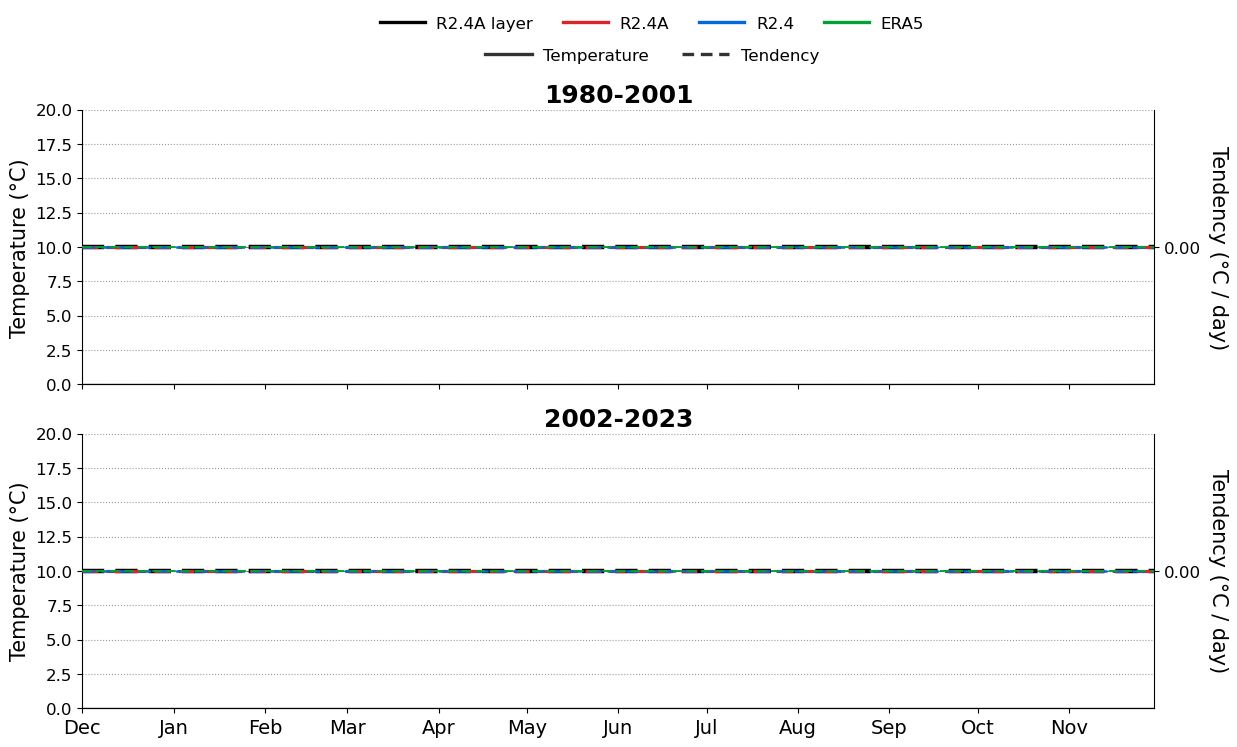

12.179166666666669 7.276279186495983 1.6738179438290295


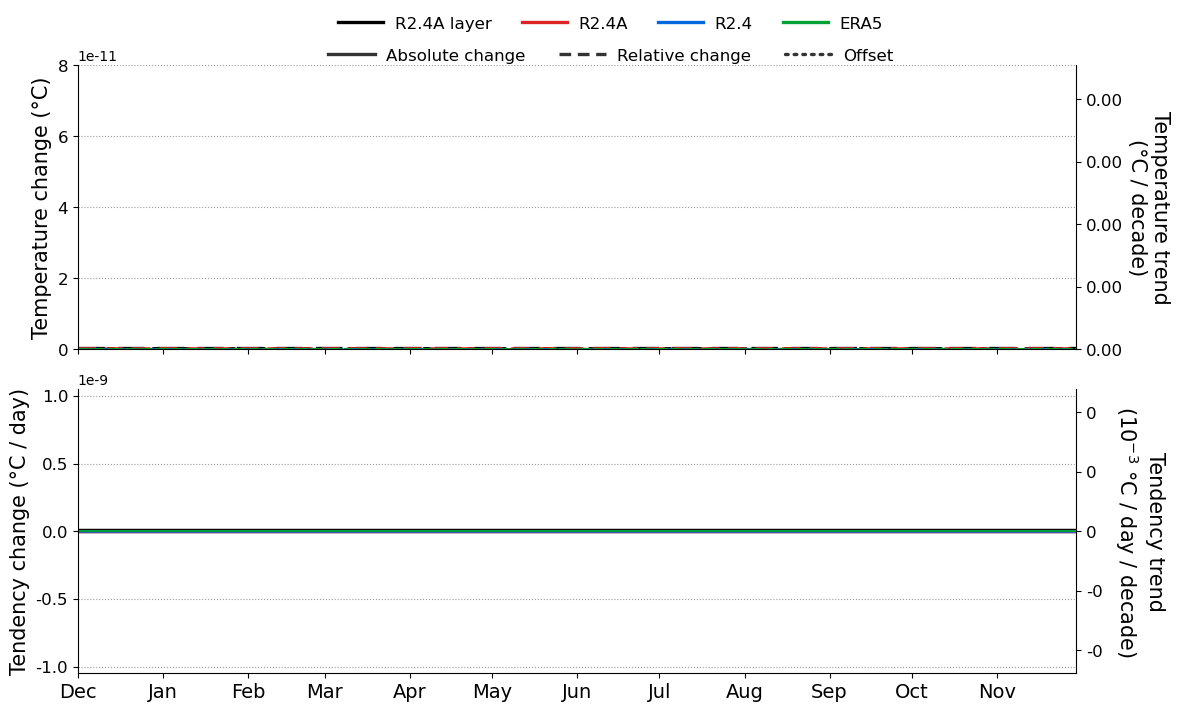

11.599377284127621 6.923888888888888 1.6752691255259347


In [ ]:
# Fix aspect ratios improve formatting and reduce code similar to the other sections
figsize_common = (13.4, 8.0)
dpi_common = 100
plot_box_aspect = 0.265
hspace_common = 0.14
fig_adjust_common = dict(left=0.075, right=0.875, bottom=0.08, top=0.84)
legend_common = dict(loc='upper center', frameon=False, handletextpad=0.7, fontsize=12)

legend_lw = 2.4
dash_daily = (5.0, 2.5)
dash_shape = (5.0, 2.5)
dot_offset = (1.0, 2.0)

series = available_temp_series(require=[(clim_temp, 'clim_temp'), (clim_tendtot, 'clim_tendtot')])
if not series:
    raise ValueError('No valid series found in selected_series')

ref = clim_temp[series[0]['dataset']][series[0]['var']]['PtrendL']
x = month_day_axis(ref['month_day'].values)
month_ticks = month_tick_positions()

plot_data = {}
for s in series:
    ds, var, label = s['dataset'], s['var'], s['label']
    temp_L = clim_temp[ds][var]['PtrendL']
    temp_R = clim_temp[ds][var]['PtrendR']
    tend_L = clim_tendtot[ds][var]['PtrendL']
    tend_R = clim_tendtot[ds][var]['PtrendR']
    dtemp = (temp_R - temp_L).astype('float32')

    plot_data[label] = {
        'temp_L': temp_L,
        'temp_R': temp_R,
        'tend_L': tend_L,
        'tend_R': tend_R,
        'dtemp': dtemp,
        'dtend': (tend_R - tend_L).astype('float32'),
        'recon_shape': shape_tendtot[ds]['day']['Ptrend'][var]['Theta'].astype('float32').sel(month_day=dtemp['month_day']),
        'offset_line': xr.full_like(dtemp, float(annual_offset_tendtot[ds]['day']['Ptrend'][var]['offset']['total'].item())).astype('float32'),
    }

temp_ylim = (0, 20)
tend_ylim = limits(stack_values(v[k].values for v in plot_data.values() for k in ['tend_L', 'tend_R']), symmetric=True, pad=0.05)
change_ylim = limits(stack_values(v[k].values for v in plot_data.values() for k in ['dtemp', 'recon_shape', 'offset_line']), pad=0.08, zero=True)
dtend_ylim = limits(stack_values(v['dtend'].values for v in plot_data.values()), symmetric=True, pad=0.05)

color_handles = series_handles(series, lw=legend_lw)
period_handles = [
    Line2D([0], [0], color='0.2', lw=legend_lw, label='Temperature'),
    Line2D([0], [0], color='0.2', lw=legend_lw, ls='--', dashes=(3.5, 2), label='Tendency'),
]
change_handles = [
    Line2D([0], [0], color='0.2', lw=legend_lw, label='Absolute change'),
    Line2D([0], [0], color='0.2', lw=legend_lw, ls='--', dashes=(3.5, 2), label='Relative change'),
    Line2D([0], [0], color='0.2', lw=legend_lw, ls=':', dashes=(0.8, 1.8), dash_capstyle='round', label='Offset'),
]

# Figure 1
fig, axes = plt.subplots(2, 1, figsize=figsize_common, dpi=dpi_common, sharex=True, gridspec_kw={'hspace': hspace_common})
fig.subplots_adjust(**fig_adjust_common, hspace=hspace_common)

for ax, side, title in zip(axes, ['L', 'R'], [period_label('PtrendL'), period_label('PtrendR')]):
    ax2 = ax.twinx()
    for s in series:
        d = plot_data[s['label']]
        ax.plot(x, d[f'temp_{side}'], color=s['color'], lw=s['lw_temp'])
        ax2.plot(x, d[f'tend_{side}'], color=s['color'], lw=s['lw_tend'], ls='--', dashes=dash_daily)

    style_calendar_axis(ax, x, month_ticks, bottom=ax is axes[-1])
    style_twin_axis(ax2)
    ax.set_box_aspect(plot_box_aspect)
    ax.set_title(title, fontsize=18, pad=5, fontweight='bold')
    ax.set_ylabel('Temperature (°C)', fontsize=15)
    ax.set_ylim(temp_ylim)
    ax.yaxis.set_major_locator(MultipleLocator(2.5))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=12)

    ax2.set_ylim(tend_ylim)
    ax2.set_ylabel('Tendency (°C / day)', rotation=270, labelpad=12, va='center', fontsize=15)
    ax2.yaxis.set_major_locator(MultipleLocator(0.05))
    ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax2.tick_params(axis='y', labelsize=12)

fig.legend(handles=color_handles, bbox_to_anchor=(0.5, 0.97), ncol=len(series), handlelength=2.7, columnspacing=1.8, **legend_common)
fig.legend(handles=period_handles, bbox_to_anchor=(0.5, 0.93), ncol=2, handlelength=2.8, columnspacing=2.0, **legend_common)
match_tight_aspect(fig, axes, box_aspect=plot_box_aspect)
plt.show()
fig.canvas.draw()
bbox = fig.get_tightbbox(fig.canvas.get_renderer())
print(bbox.width, bbox.height, bbox.width / bbox.height)


# Figure 2
trend_scale = 10.0 / float(offset_L['Ptrend'].item())
fig, axes = plt.subplots(2, 1, figsize=figsize_common, dpi=dpi_common, sharex=True, gridspec_kw={'hspace': hspace_common})
fig.subplots_adjust(**fig_adjust_common, hspace=hspace_common)
ax_top, ax_bot = axes

for s in series:
    d = plot_data[s['label']]
    ax_top.plot(x, d['dtemp'], color=s['color'], lw=s['lw_temp'])
    ax_top.plot(x, d['recon_shape'], color=s['color'], lw=s['lw_temp'], ls='--', dashes=dash_shape)
    ax_top.plot(x, d['offset_line'], color=s['color'], lw=s['lw_temp'] * 0.95, ls=':', dashes=dot_offset, dash_capstyle='round')
    ax_bot.plot(x, d['dtend'], color=s['color'], lw=s['lw_tend'])

for ax, ylabel, ylim in [
    (ax_top, 'Temperature change (°C)', change_ylim),
    (ax_bot, 'Tendency change (°C / day)', dtend_ylim),
]:
    style_calendar_axis(ax, x, month_ticks, bottom=ax is ax_bot)
    ax.set_box_aspect(plot_box_aspect)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_ylim(ylim)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=12)

secondary_axes = [
    (ax_top.secondary_yaxis('right', functions=(lambda y: y * trend_scale, lambda y: y / trend_scale)), 'Temperature trend\n(°C / decade)', '%.2f', 18),
    (ax_bot.secondary_yaxis('right', functions=(lambda y: y * trend_scale * 1e3, lambda y: y / (trend_scale * 1e3))), r'Tendency trend' + '\n' + r'($10^{-3}$ °C / day / decade)', '%.0f', 26),
]
for secax, ylabel, formatter, labelpad in secondary_axes:
    secax.set_ylabel(ylabel, fontsize=15, rotation=270, labelpad=labelpad, va='center')
    secax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    secax.yaxis.set_major_formatter(FormatStrFormatter(formatter))
    secax.tick_params(axis='y', labelsize=12)

fig.legend(handles=color_handles, bbox_to_anchor=(0.5, 0.92), ncol=len(series), handlelength=2.7, columnspacing=1.8, **legend_common)
fig.legend(handles=change_handles, bbox_to_anchor=(0.5, 0.88), ncol=3, handlelength=2.8, columnspacing=2.0, **legend_common)
match_tight_aspect(fig, axes, box_aspect=plot_box_aspect)
plt.show()

fig.canvas.draw()
bbox = fig.get_tightbbox(fig.canvas.get_renderer())
print(bbox.width, bbox.height, bbox.width / bbox.height)


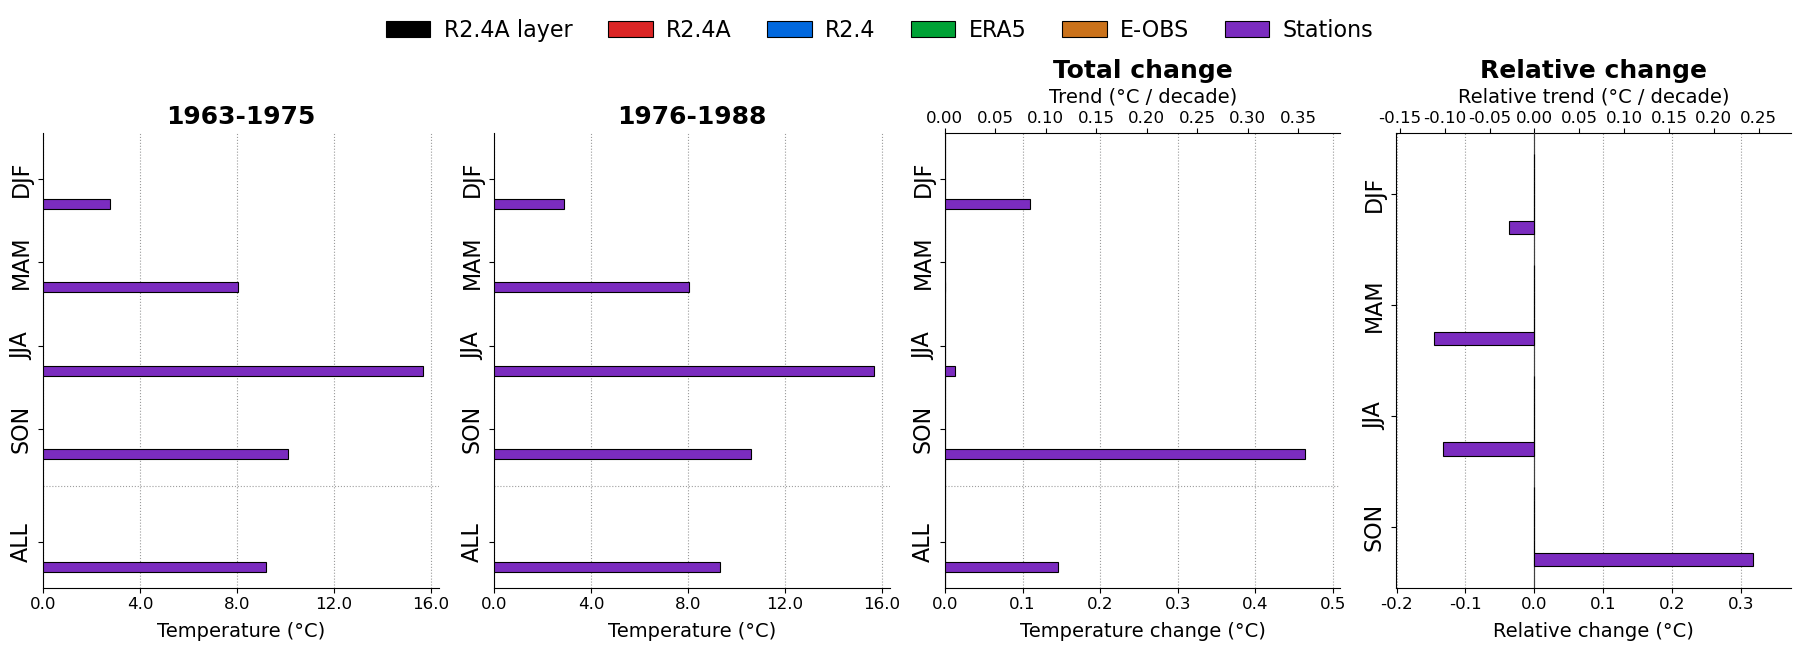

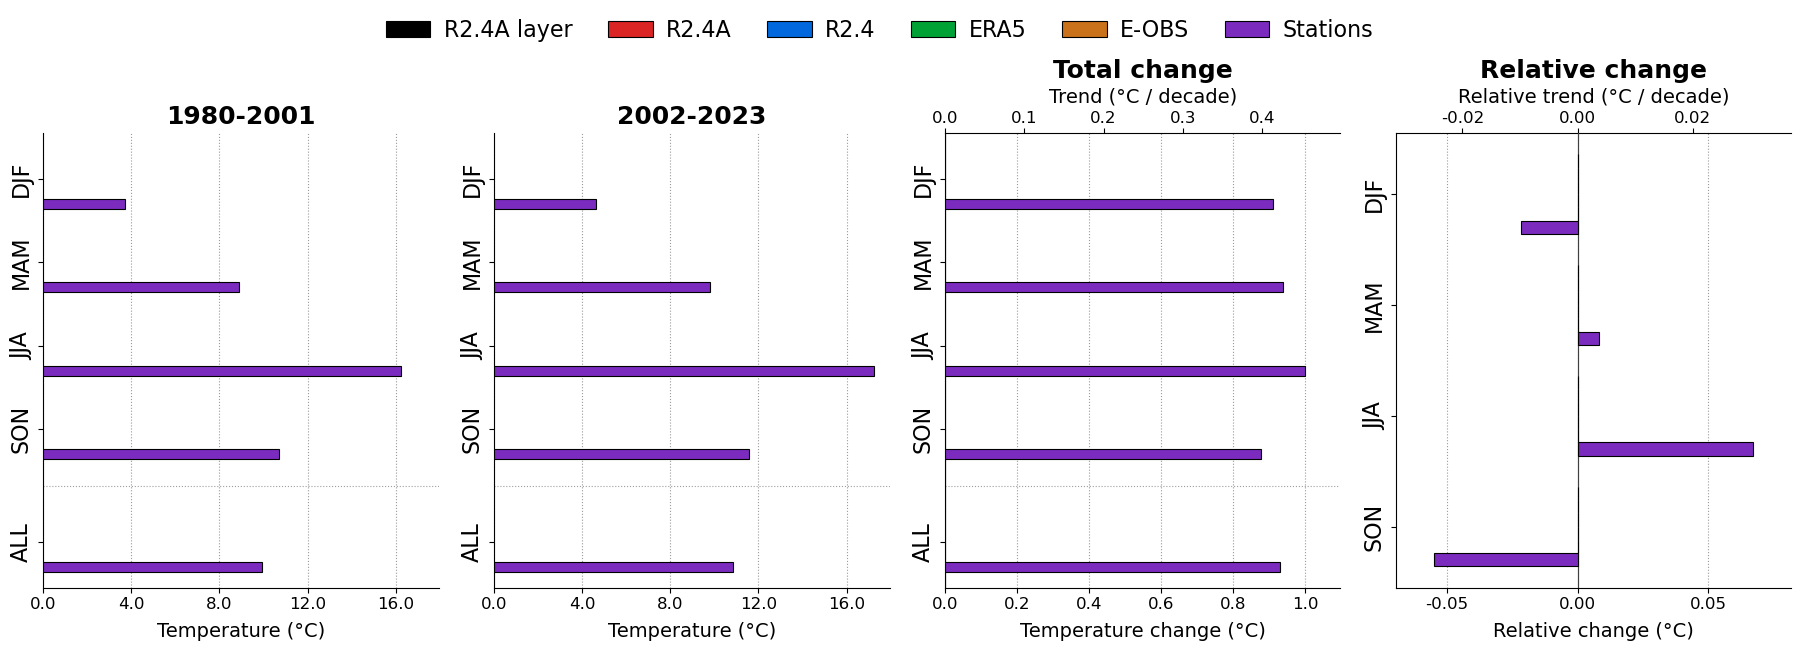

In [ ]:
# Temperature seasonal changes
series = available_temp_series(all_tg=True)
for s in series:
    s['linewidth'] = 0.8

pair_to_period = {('PrefL', 'PrefR'): 'Pref', ('PtrendL', 'PtrendR'): 'Ptrend'}
season_order_main = ['DJF', 'MAM', 'JJA', 'SON', 'ALL']
season_order_rel = ['DJF', 'MAM', 'JJA', 'SON']
y_main = np.array([0.0, 1.0, 2.0, 3.0, 4.35])
y_rel = np.arange(len(season_order_rel), dtype=float)
handles = series_handles(series, kind='patch')

for left_key, right_key in [('PrefL', 'PrefR'), ('PtrendL', 'PtrendR')]:
    period_key = pair_to_period[(left_key, right_key)]
    seasonal = {}
    relative = {}

    for s in series:
        ds, var, label = s['dataset'], s['var'], s['label']
        left_season = aggregate_calendar(clim_temp[ds][var][left_key], split='season', how='mean')
        right_season = aggregate_calendar(clim_temp[ds][var][right_key], split='season', how='mean')
        left = season_plus_all(left_season, clim_temp[ds][var][left_key].mean('month_day').astype('float32').item(), season_order_main)
        right = season_plus_all(right_season, clim_temp[ds][var][right_key].mean('month_day').astype('float32').item(), season_order_main)

        seasonal[label] = {left_key: left, right_key: right, 'Diff': (right - left).astype('float32')}
        relative[label] = shape_tendtot[ds]['season'][period_key][var]['Theta'].sel(season=season_order_rel).astype('float32')

    temp_vals = stack_values(seasonal[s['label']][k].values for s in series for k in [left_key, right_key])
    diff_vals = stack_values(seasonal[s['label']]['Diff'].values for s in series)
    rel_vals = stack_values(relative[s['label']].values for s in series)
    temp_xlim = limits(temp_vals, pad=0.04, zero=True)
    diff_xlim = limits(diff_vals, pad=0.10, zero=True)
    rel_xlim = limits(rel_vals, pad=0.12, zero=True)

    fig, axes = plt.subplots(
        1, 4,
        figsize=(18.8, 6.4),
        gridspec_kw={'width_ratios': [1, 1, 1, 1], 'wspace': 0.14},
    )
    fig.subplots_adjust(left=0.055, right=0.985, bottom=0.13, top=0.84)
    ax0, ax1, ax2, ax3 = axes

    draw_grouped_hbars(ax0, series, {s['label']: seasonal[s['label']][left_key] for s in series}, season_order_main, y_main, all_separator=True)
    draw_grouped_hbars(ax1, series, {s['label']: seasonal[s['label']][right_key] for s in series}, season_order_main, y_main, all_separator=True)
    draw_grouped_hbars(ax2, series, {s['label']: seasonal[s['label']]['Diff'] for s in series}, season_order_main, y_main, all_separator=True)
    draw_grouped_hbars(ax3, series, relative, season_order_rel, y_rel)

    for ax, title, xlabel, xlim, zero in [
        (ax0, period_label(left_key), 'Temperature (°C)', temp_xlim, False),
        (ax1, period_label(right_key), 'Temperature (°C)', temp_xlim, False),
        (ax2, 'Total change', 'Temperature change (°C)', diff_xlim, True),
        (ax3, 'Relative change', 'Relative change (°C)', rel_xlim, True),
    ]:
        style_hbar(
            ax, title, xlabel, zero=zero, bold=True,
            formatter='%.1f' if ax in [ax0, ax1] else '%.2f',
            title_fontsize=18,
            x_tick_fontsize=12,
            y_tick_fontsize=16,
            y_tick_rotation=90,
            label_fontsize=14,
        )
        ax.set_xlim(*xlim)
    
    for ax in [ax0, ax1, ax2, ax3]:
        center_y_ticklabels(ax, rotation=90, pad=12)

    set_step_ticks(ax2, candidates=(0.05, 0.1, 0.2), max_ticks=7)
    set_step_ticks(ax3, candidates=(0.05, 0.1, 0.2), max_ticks=11)

    L = float(weights_kappa(periods[left_key], periods[right_key]).sum('year').item())

    add_scaled_top_axis(
        ax2, 10.0 / L, 'Trend (°C / decade)',
        tick_fontsize=12, label_fontsize=14
    )
    add_scaled_top_axis(
        ax3, 10.0 / L, 'Relative trend (°C / decade)',
        steps=(0.02, 0.05, 0.1, 0.2),
        tick_fontsize=12, label_fontsize=14
    )

    fig.legend(
        handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05),
        ncol=len(handles), frameon=False, columnspacing=1.6,
        handletextpad=0.6, fontsize=16
    )
    plt.show()


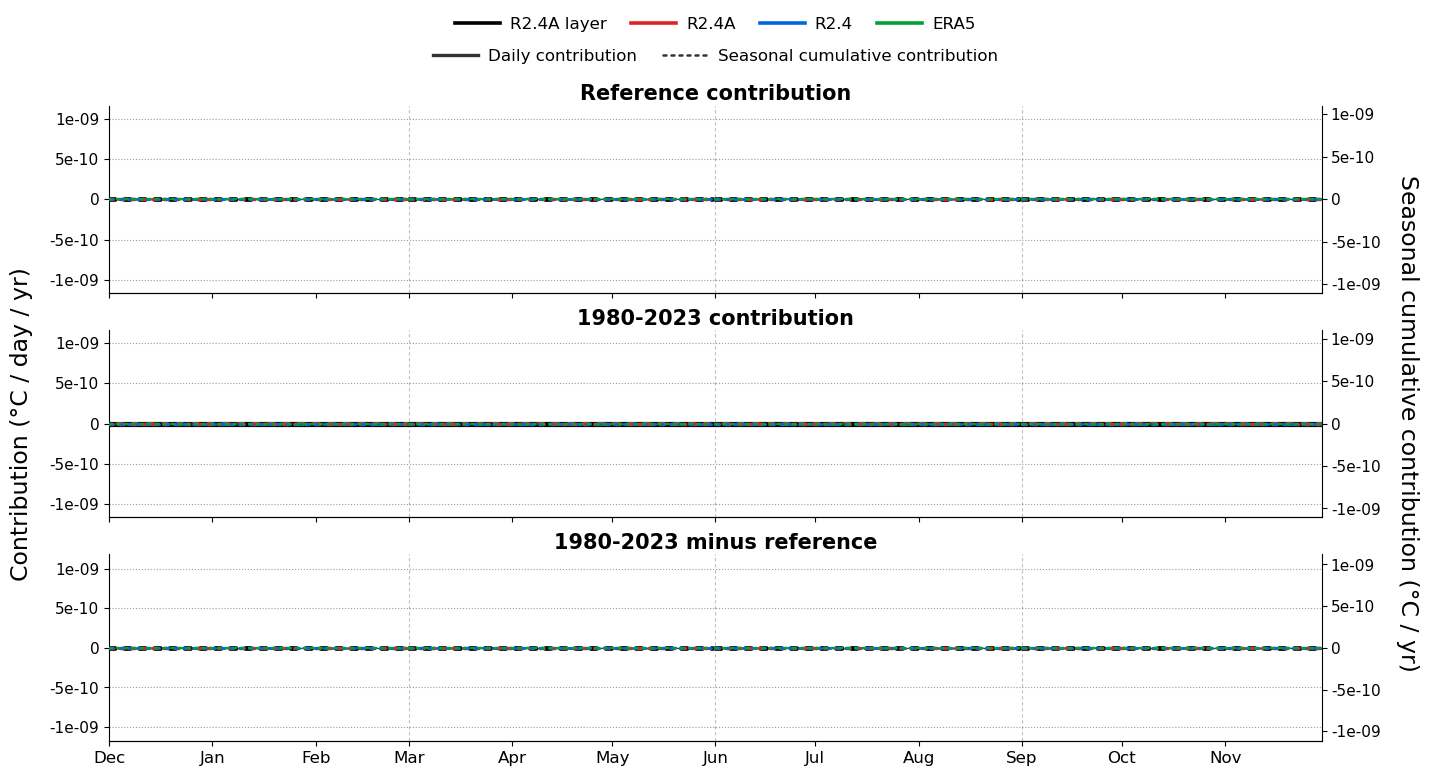

In [ ]:
series = []
plot_data = {}
reference_key = 'Reference'
reference_label = 'Reference contribution' if reference_mode == 'stationary' else f'Reference period ({period_label(reference_period_key)})'
reference_short_label = 'reference' if reference_mode == 'stationary' else period_label(reference_period_key)
dot_cumulative = (1.2, 2.0)
show_end_values = False

def season_slices_for_month_day(month_day_values):
    month = pd.Index(month_day_values.astype(str)).str.slice(0, 2).astype(int).to_numpy()
    season = np.empty(month.size, dtype='<U3')
    season[np.isin(month, [12, 1, 2])] = 'DJF'
    season[np.isin(month, [3, 4, 5])] = 'MAM'
    season[np.isin(month, [6, 7, 8])] = 'JJA'
    season[np.isin(month, [9, 10, 11])] = 'SON'
    breaks = np.r_[0, np.where(season[1:] != season[:-1])[0] + 1, len(season)]
    return [slice(int(breaks[i]), int(breaks[i + 1])) for i in range(len(breaks) - 1)]

def seasonal_cumsum(daily):
    return [daily.isel(month_day=part).cumsum('month_day').astype('float32') for part in season_slices_for_month_day(daily['month_day'].values)]

for s in available_temp_series():
    ds, var, label = s['dataset'], s['var'], s['label']
    try:
        ref = clean_1d(ref_tendency(var, dataset=ds), 'month_day')
        ptrend = tendency_split(ds, var, 'Ptrend')
    except KeyError:
        print(f'Skipping {ds} {var}, not found in reference data or annual_offset_tendtot')
        continue

    for period_name, daily, stored_total in [
        (reference_short_label, ref, ref_tendency(var, total=True, dataset=ds)),
        ('Ptrend', ptrend, annual_offset_tendtot[ds]['day']['Ptrend'][var]['trend']['total']),
    ]:
        split_total = to_float(daily.sum('month_day'))
        stored_total = to_float(stored_total)
        if not np.isclose(split_total, stored_total, rtol=1e-4, atol=1e-7):
            print(f'Check {ds} {var} {period_name}: daily split sums to {split_total:.4g}, stored total is {stored_total:.4g}')

    plot_data[label] = {reference_key: ref, 'Ptrend': ptrend, 'Change': (ptrend - ref).astype('float32')}
    series.append(s)

if not series:
    raise ValueError('No valid series found in selected_series')

min_daily_lw = min(s['lw_increment'] for s in series)
daily_lw = {
    s['label']: 0.45 + min_daily_lw + 2.15 * (s['lw_increment'] - min_daily_lw)
    for s in series
}

ref = plot_data[series[0]['label']]['Ptrend']
x = month_day_axis(ref['month_day'].values)
month_ticks = month_tick_positions()
season_boundaries = [x[part.start] for part in season_slices_for_month_day(ref['month_day'].values)[1:]]
period_titles = {
    reference_key: reference_label,
    'Ptrend': f'{period_label("Ptrend")} contribution',
    'Change': f'{period_label("Ptrend")} minus {reference_short_label}',
}
end_titles = {
    reference_key: 'Total\n(°C / decade)',
    'Ptrend': 'Total\n(°C / decade)',
    'Change': 'Total change\n(°C / decade)',
}

cumulative_period_values = []
increment_period_values = []
cumulative_change_values = []
increment_change_values = []
for s in series:
    label = s['label']
    for key in [reference_key, 'Ptrend']:
        daily = plot_data[label][key]
        cumulative_period_values.extend(part.values for part in seasonal_cumsum(daily))
        increment_period_values.append(daily.values)
    daily_change = plot_data[label]['Change']
    cumulative_change_values.extend(part.values for part in seasonal_cumsum(daily_change))
    increment_change_values.append(daily_change.values)

cumulative_period_ylim = limits(stack_values(cumulative_period_values), pad=0.10, symmetric=True)
increment_period_ylim = limits(stack_values(increment_period_values), pad=0.16, symmetric=True)
cumulative_change_ylim = limits(stack_values(cumulative_change_values), pad=0.12, symmetric=True)
increment_change_ylim = limits(stack_values(increment_change_values), pad=0.18, symmetric=True)

fig = plt.figure(figsize=(14.1, 8.2))
if show_end_values:
    main_col_width = 18.0
    side_col_width = 2.0
    gs = fig.add_gridspec(3, 2, width_ratios=[main_col_width, side_col_width], hspace=0.20, wspace=0.20)
    axes = [fig.add_subplot(gs[0, 0])]
    axes += [fig.add_subplot(gs[row, 0], sharex=axes[0]) for row in [1, 2]]
    end_axes = [fig.add_subplot(gs[row, 1]) for row in range(3)]
    fig.subplots_adjust(top=0.86, left=0.080, right=0.970, bottom=0.085)
    legend_x = 0.080 + 0.5 * (0.970 - 0.080) * (main_col_width / (main_col_width + side_col_width))
else:
    gs = fig.add_gridspec(3, 1, hspace=0.20)
    axes = [fig.add_subplot(gs[0, 0])]
    axes += [fig.add_subplot(gs[row, 0], sharex=axes[0]) for row in [1, 2]]
    end_axes = [None, None, None]
    fig.subplots_adjust(top=0.86, left=0.080, right=0.940, bottom=0.085)
    legend_x = 0.51

cumulative_axes = []
for row, key in enumerate([reference_key, 'Ptrend', 'Change']):
    ax = axes[row]
    ax_cumulative = ax.twinx()
    cumulative_axes.append(ax_cumulative)
    end_values_decade = []
    end_colors = []

    for s in series:
        daily = plot_data[s['label']][key]
        cumulative_parts = seasonal_cumsum(daily)
        ax.plot(x, daily.values, color=s['color'], lw=daily_lw[s['label']], solid_capstyle='round', zorder=4)
        for cumulative in cumulative_parts:
            ax_cumulative.plot(month_day_axis(cumulative['month_day'].values), cumulative.values, color=s['color'], lw=s['lw_cumulative'], ls=':', dashes=dot_cumulative, dash_capstyle='round', solid_capstyle='round', zorder=3)
        end_values_decade.append(10.0 * float(daily.sum('month_day').item()))
        end_colors.append(s['color'])

    ax.set_title(period_titles[key], fontsize=15, pad=4, fontweight='bold')
    for boundary in season_boundaries:
        ax.axvline(boundary, color='0.45', lw=0.8, ls='--', dashes=(3.0, 2.4), alpha=0.45, zorder=1)
    style_calendar_axis(ax, x, month_ticks, bottom=row == 2)
    style_twin_axis(ax_cumulative)
    if show_end_values:
        draw_end_values(end_axes[row], end_titles[key], end_values_decade, end_colors)
    ax.set_ylim(*(increment_change_ylim if key == 'Change' else increment_period_ylim))
    ax_cumulative.set_ylim(*(cumulative_change_ylim if key == 'Change' else cumulative_period_ylim))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_formatter(FuncFormatter(compact_tick))
    ax.tick_params(axis='y', labelsize=11)
    ax_cumulative.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_cumulative.yaxis.set_major_formatter(FuncFormatter(compact_tick))
    ax_cumulative.tick_params(axis='y', labelsize=11, pad=3, colors='black')

axes[1].set_ylabel('Contribution (°C / day / yr)', fontsize=17, labelpad=12)
cumulative_axes[1].set_ylabel('Seasonal cumulative contribution (°C / yr)', rotation=270, labelpad=28, fontsize=17, color='black')

fig.legend(handles=series_handles(series, lw=2.6), loc='upper center', bbox_to_anchor=(legend_x, 0.98), ncol=len(series), frameon=False, fontsize=12, handlelength=2.7, handletextpad=0.6, columnspacing=1.45, borderaxespad=0.15)
fig.legend(
    handles=[
        Line2D([0], [0], color='0.20', lw=2.4, label='Daily contribution'),
        Line2D([0], [0], color='0.20', lw=1.8, ls=':', dashes=dot_cumulative, dash_capstyle='round', label='Seasonal cumulative contribution'),
    ],
    loc='upper center', bbox_to_anchor=(legend_x, 0.94), ncol=2, frameon=False, fontsize=12, handlelength=2.7, handletextpad=0.6, columnspacing=1.55, borderaxespad=0.10,
)
plt.show()

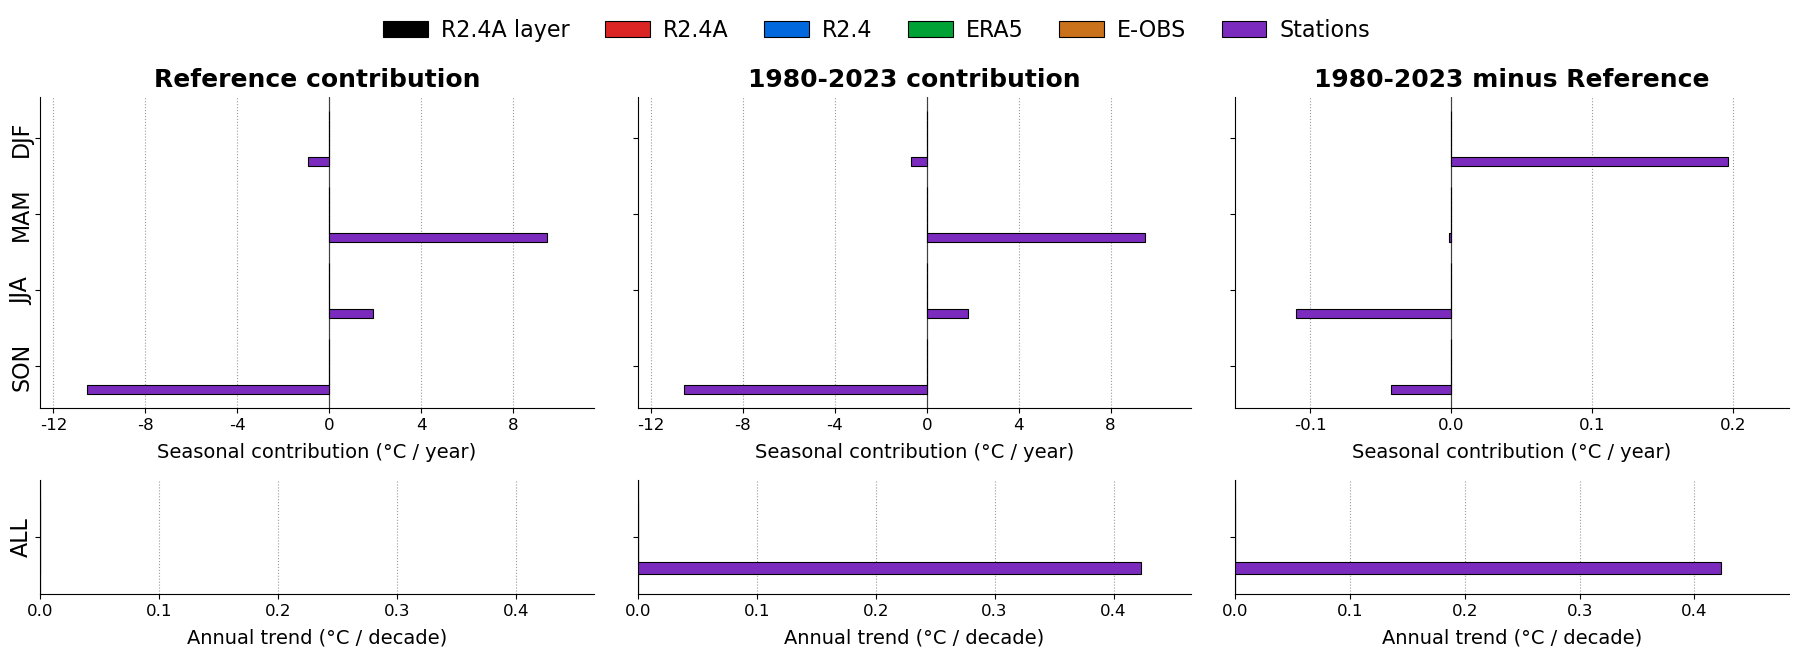

In [ ]:
# Seasonal annual-offset bars
season_names = ['DJF', 'MAM', 'JJA', 'SON']
annual_scale = 10.0
reference_key = 'Reference'
annual_reference_key = 'AnnualReference'
reference_label = 'Reference contribution' if reference_mode == 'stationary' else f'Reference ({period_label(reference_period_key)})'
reference_short_label = 'Reference' if reference_mode == 'stationary' else period_label(reference_period_key)

series = []
for s in available_temp_series(all_tg=True):
    ds, var = s['dataset'], s['var']
    try:
        ref = clean_1d(ref_tendency(var, split='season', dataset=ds), 'season').sel(season=season_names)
        ptrend = tendency_split(ds, var, 'Ptrend', split='season')
    except KeyError:
        print(f'Skipping {ds} {var}, not found in reference data or annual_offset_tendtot')
        continue

    for period_name, split, stored_total in [
        (reference_short_label, ref, ref_tendency(var, split='season', total=True, dataset=ds)),
        ('Ptrend', ptrend, annual_offset_tendtot[ds]['season']['Ptrend'][var]['trend']['total']),
    ]:
        split_total = to_float(split.sum('season'))
        stored_total = to_float(stored_total)
        if not np.isclose(split_total, stored_total, rtol=1e-4, atol=1e-7):
            print(f'Check {ds} {var} {period_name}: seasonal split sums to {split_total:.4g}, stored total is {stored_total:.4g}')

    annual_ref = annual_scale * to_float(ref.sum('season'))
    annual_ptrend = annual_scale * to_float(ptrend.sum('season'))
    s.update({
        'linewidth': 0.8,
        reference_key: ref,
        'Ptrend': ptrend,
        'Change': (ptrend - ref).astype('float32'),
        annual_reference_key: xr.DataArray([annual_ref], dims='season', coords={'season': ['ALL']}),
        'AnnualPtrend': xr.DataArray([annual_ptrend], dims='season', coords={'season': ['ALL']}),
        'AnnualChange': xr.DataArray([annual_ptrend - annual_ref], dims='season', coords={'season': ['ALL']}),
    })
    series.append(s)

if not series:
    raise ValueError('No valid seasonal tendency series found')

season_values = stack_values(s[key].values for s in series for key in [reference_key, 'Ptrend'])
season_change_values = stack_values(s['Change'].values for s in series)
annual_values = stack_values(s[key].values for s in series for key in [annual_reference_key, 'AnnualPtrend'])
annual_change_values = stack_values(s['AnnualChange'].values for s in series)
season_xlim = limits(season_values, pad=0.10, zero=True)
season_change_xlim = limits(season_change_values, pad=0.14, zero=True)
annual_xlim = limits(annual_values, pad=0.10, zero=True)
annual_change_xlim = limits(annual_change_values, pad=0.14, zero=True)

panel_info = [
    (reference_key, annual_reference_key, reference_label),
    ('Ptrend', 'AnnualPtrend', f'{period_label("Ptrend")} contribution'),
    ('Change', 'AnnualChange', f'{period_label("Ptrend")} minus {reference_short_label}'),
]
y_season = np.arange(len(season_names), dtype=float)
y_annual = np.array([0.0])
height = min(0.12, 0.74 / len(series))
handles = series_handles(series, kind='patch')

fig, axes = plt.subplots(
    2, 3,
    figsize=(18.8, 7.0),
    gridspec_kw={'height_ratios': [2.75, 1.0], 'hspace': 0.34, 'wspace': 0.08},
)
fig.subplots_adjust(left=0.055, right=0.985, bottom=0.13, top=0.84)

for col, (season_key, annual_key, title) in enumerate(panel_info):
    ax_season, ax_annual = axes[0, col], axes[1, col]
    draw_grouped_hbars(ax_season, series, {s['label']: s[season_key] for s in series}, season_names, y_season, height)
    draw_grouped_hbars(ax_annual, series, {s['label']: s[annual_key] for s in series}, ['ALL'], y_annual, height)

    season_xlim_use = season_change_xlim if season_key == 'Change' else season_xlim
    annual_xlim_use = annual_change_xlim if annual_key == 'AnnualChange' else annual_xlim
    style_hbar(
        ax_season, title,
        'Seasonal contribution (°C / year)', #if season_key != 'Change' else 'Contribution change (°C / year)',
        zero=True, bold=True, formatter='%.1f',
        title_fontsize=18, x_tick_fontsize=12, y_tick_fontsize=16,
        y_tick_rotation=90, label_fontsize=14,
    )
    style_hbar(
        ax_annual, xlabel='Annual trend (°C / decade)', #if annual_key != 'AnnualChange' else 'Annual trend change (°C / decade)',
        zero=True, formatter='%.1f',
        x_tick_fontsize=12, y_tick_fontsize=16,
        y_tick_rotation=90, label_fontsize=14,
    )
    ax_season.set_xlim(*season_xlim_use)
    ax_annual.set_xlim(*annual_xlim_use)
    set_step_ticks(ax_season, candidates=(0.05, 0.1, 0.2, 4.0), max_ticks=7)
    set_step_ticks(ax_annual, candidates=(0.05, 0.1, 0.2), max_ticks=7)

    center_y_ticklabels(ax_season, rotation=90, pad=10)
    center_y_ticklabels(ax_annual, rotation=90, pad=10)
    if col != 0:
        ax_season.tick_params(axis='y', labelleft=False)
        ax_annual.tick_params(axis='y', labelleft=False)

fig.legend(
    handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.98),
    ncol=len(handles), frameon=False, columnspacing=1.6,
    handletextpad=0.6, fontsize=16
)
plt.show()

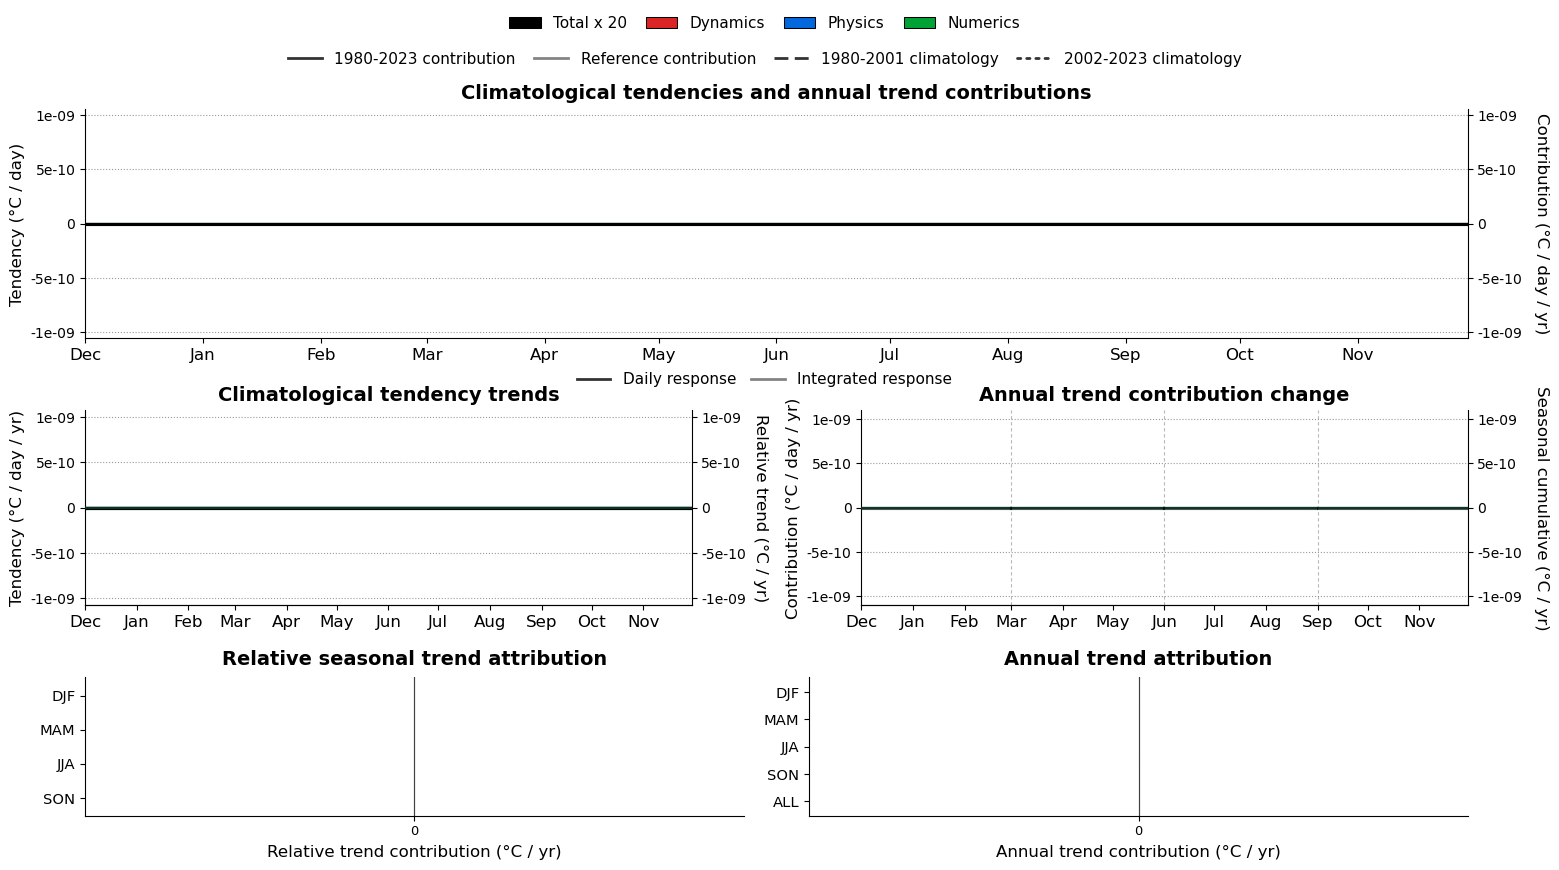

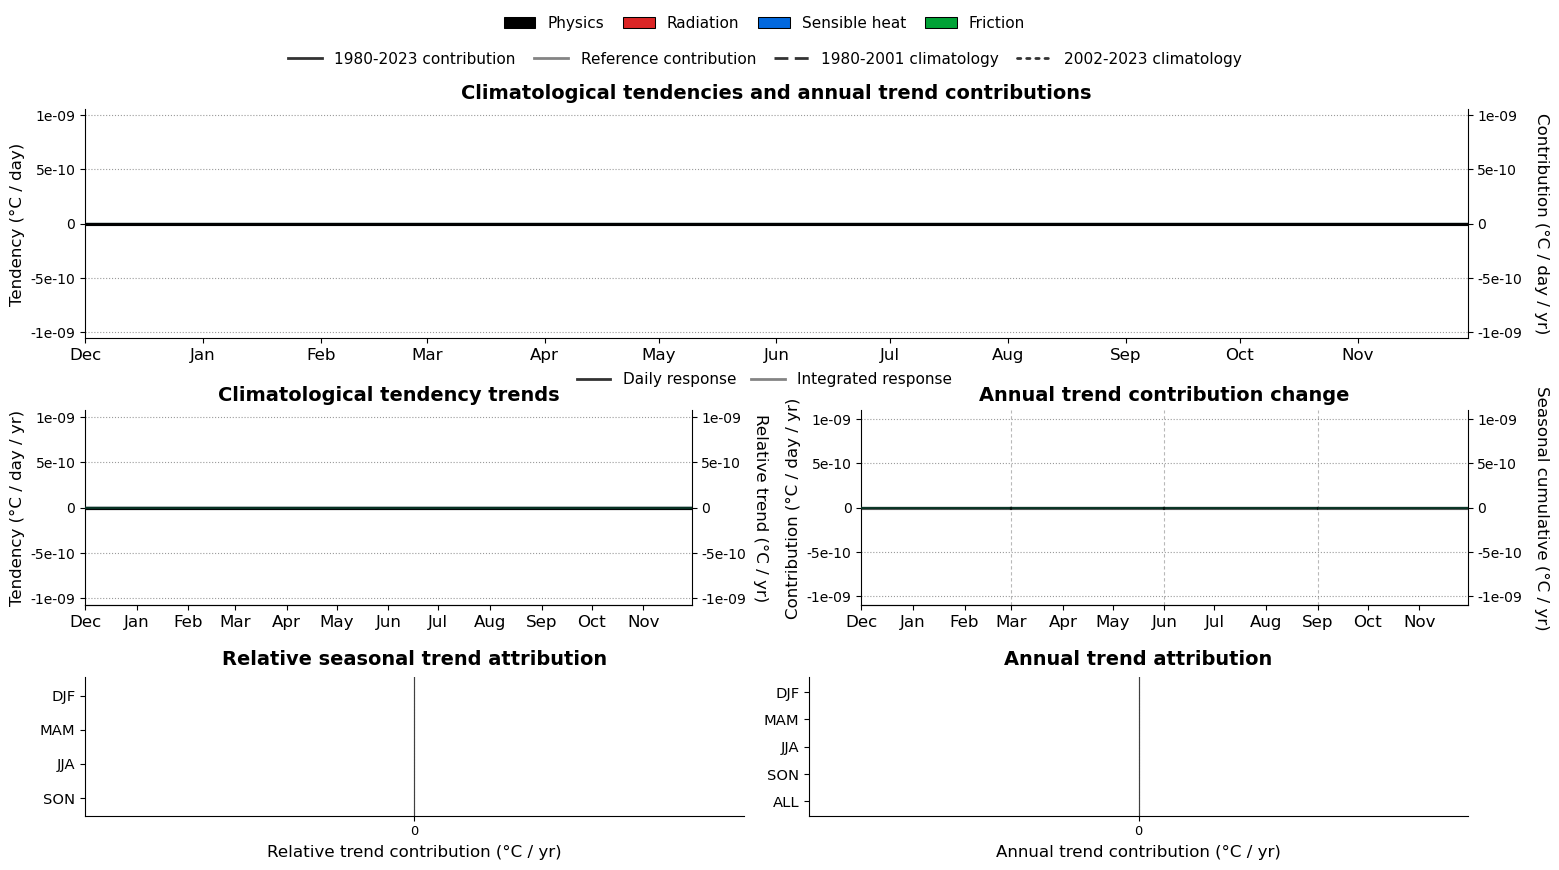

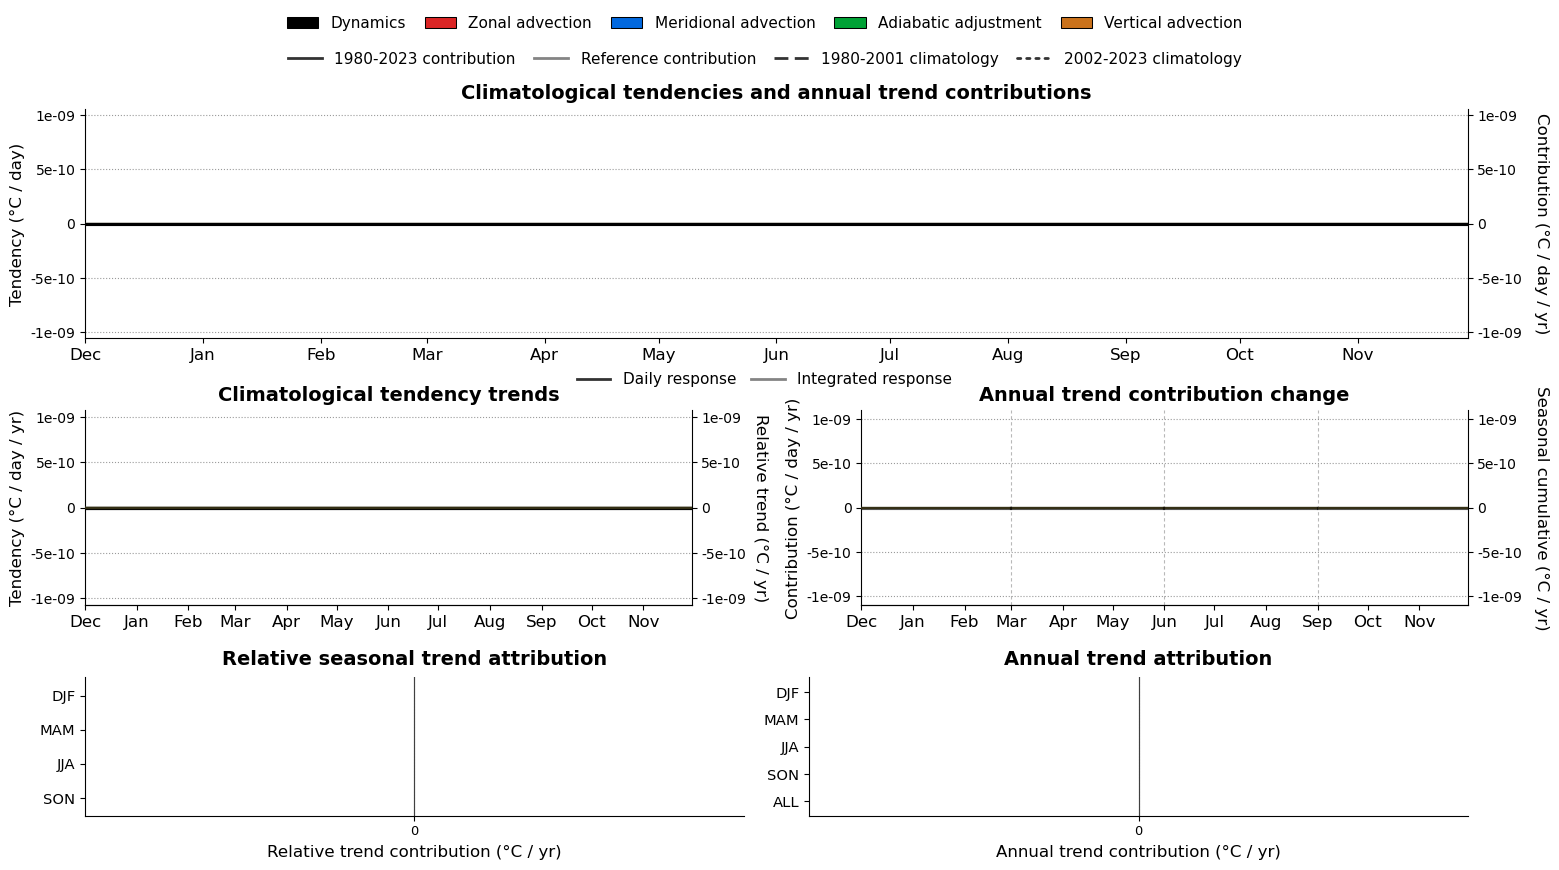

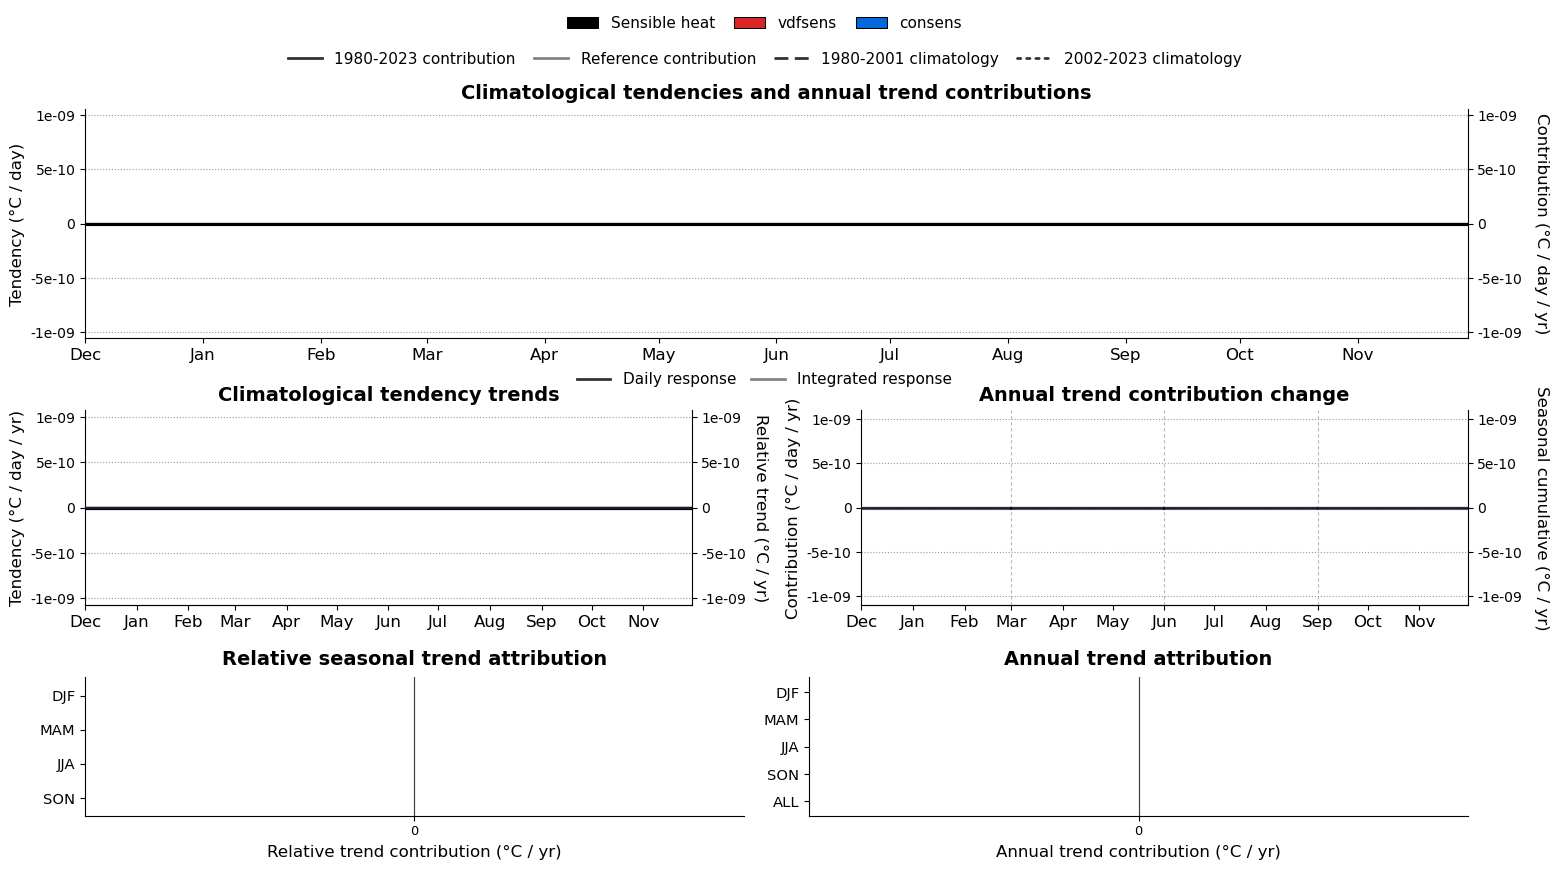

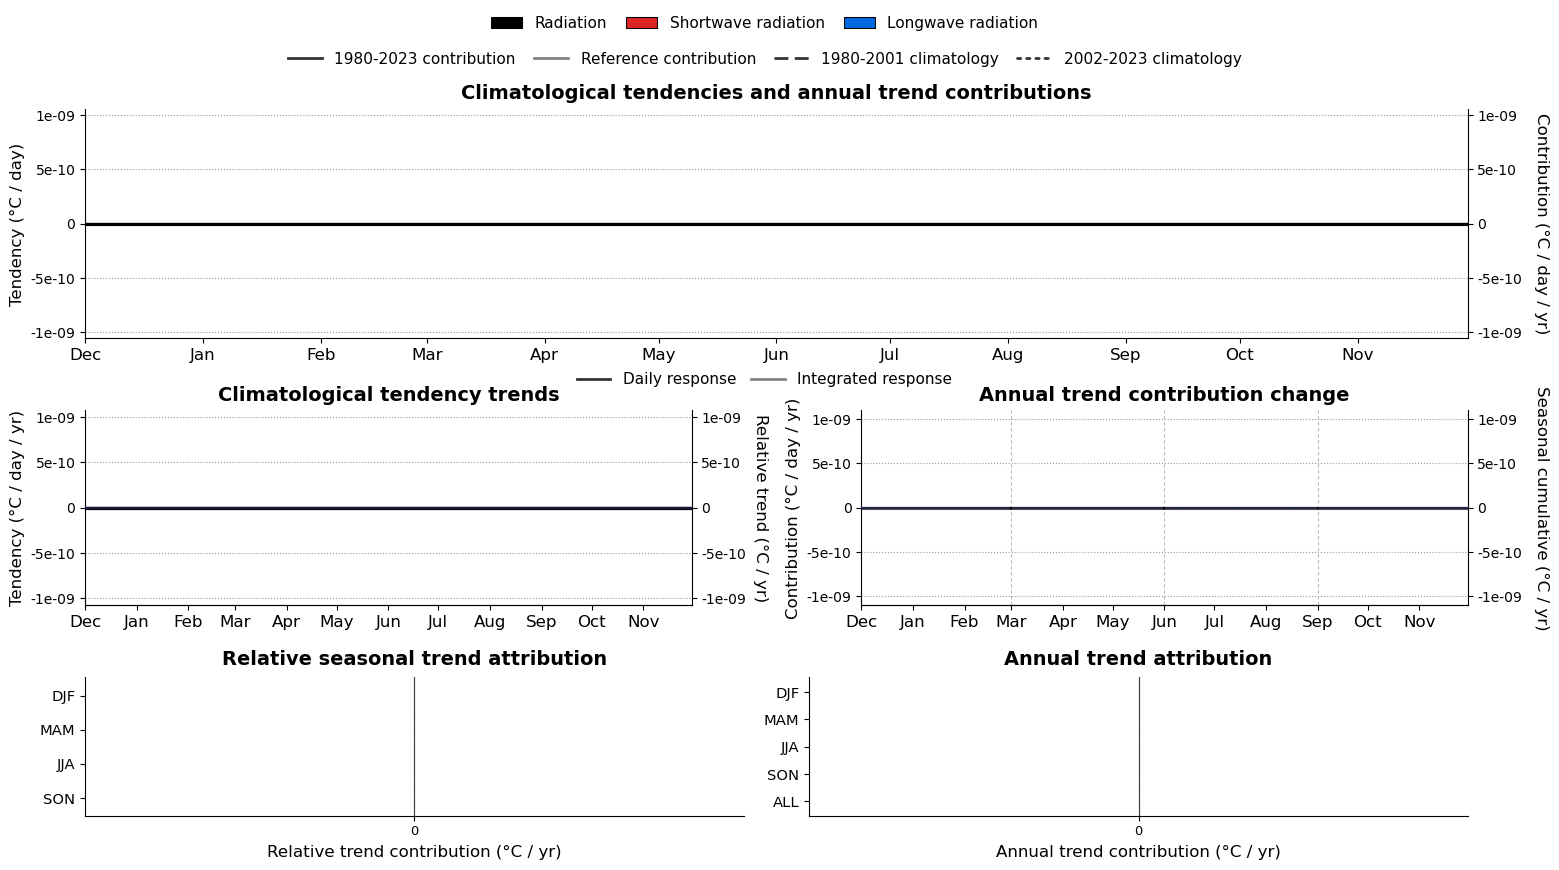

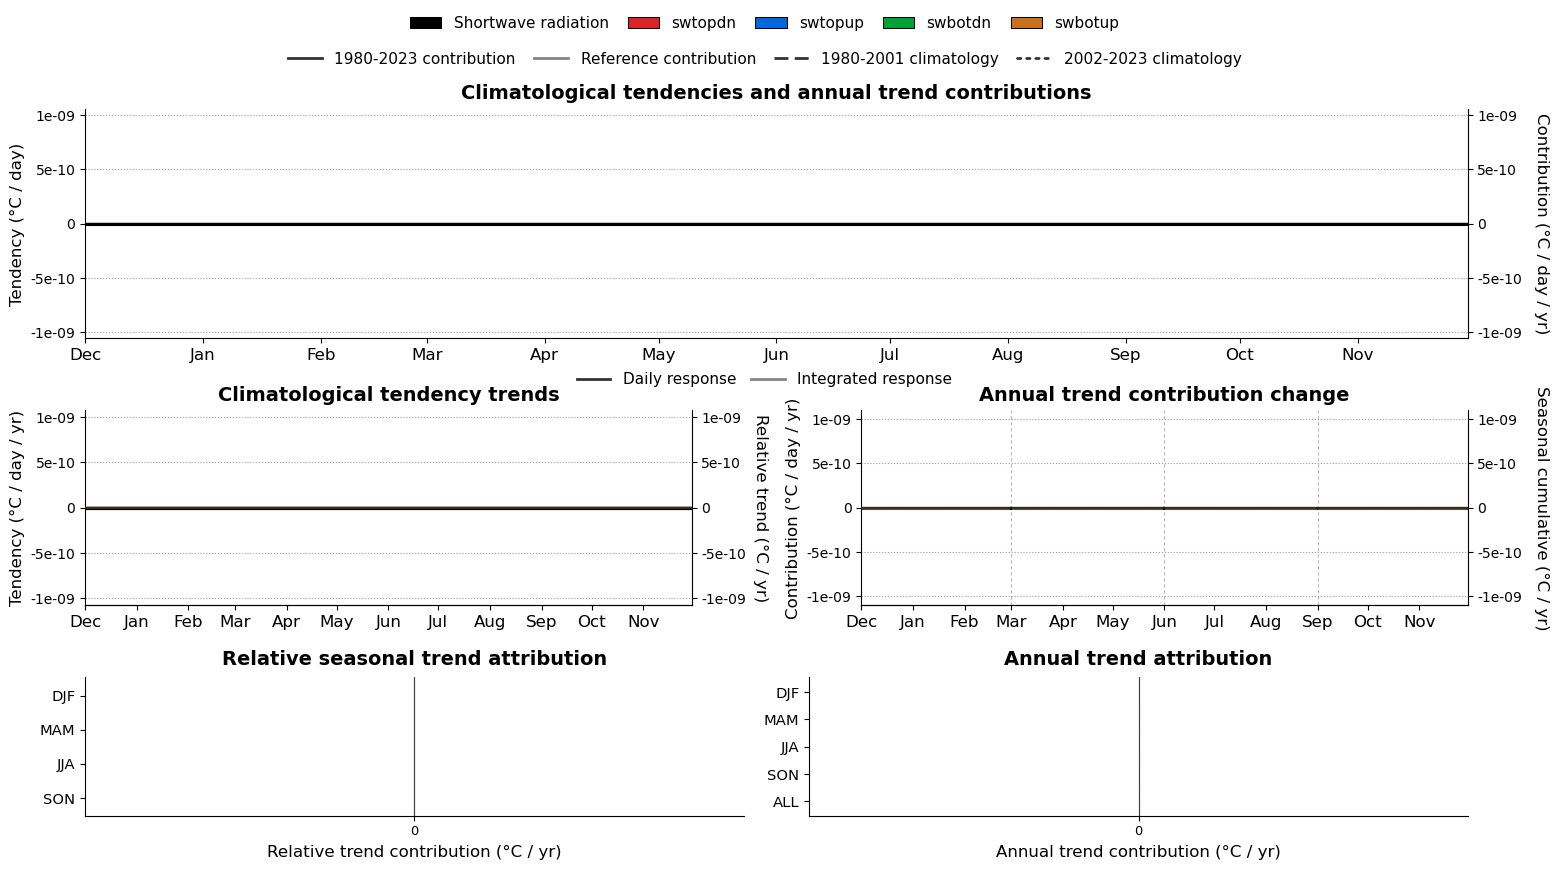

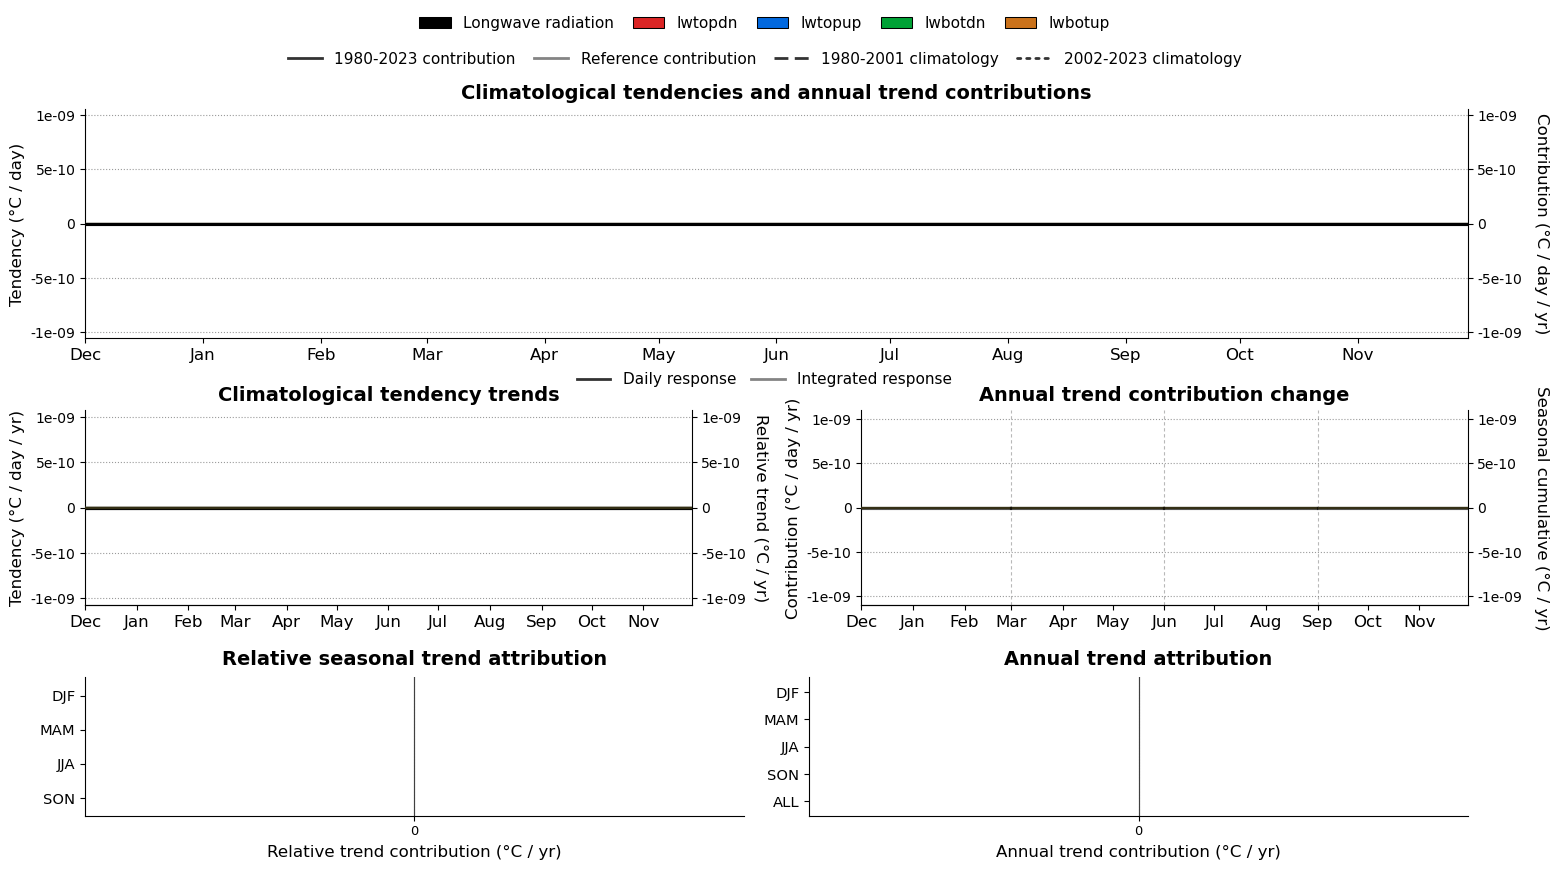

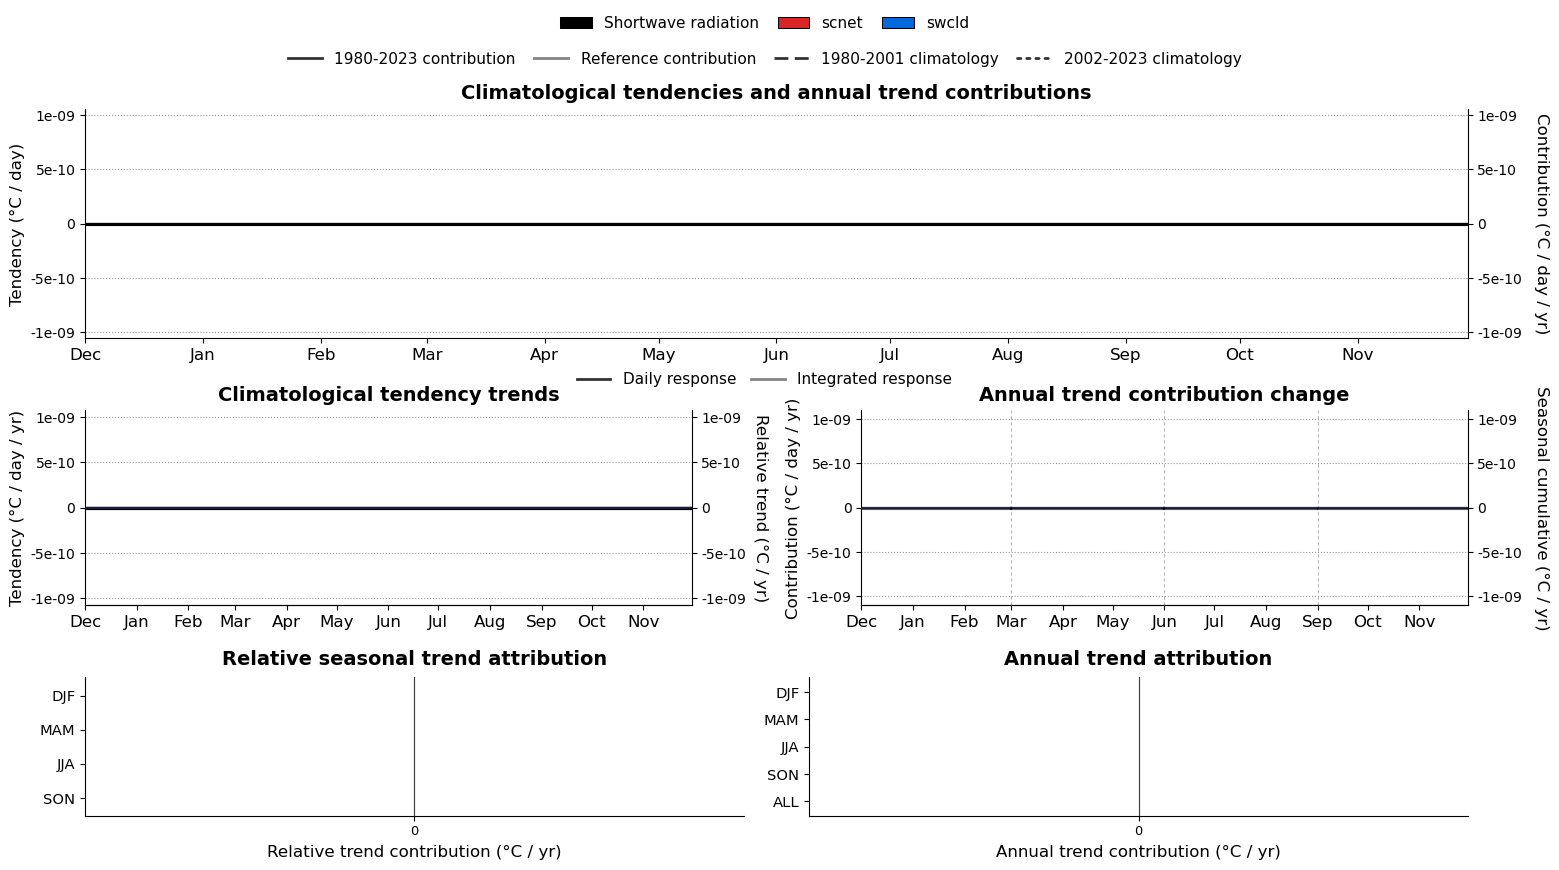

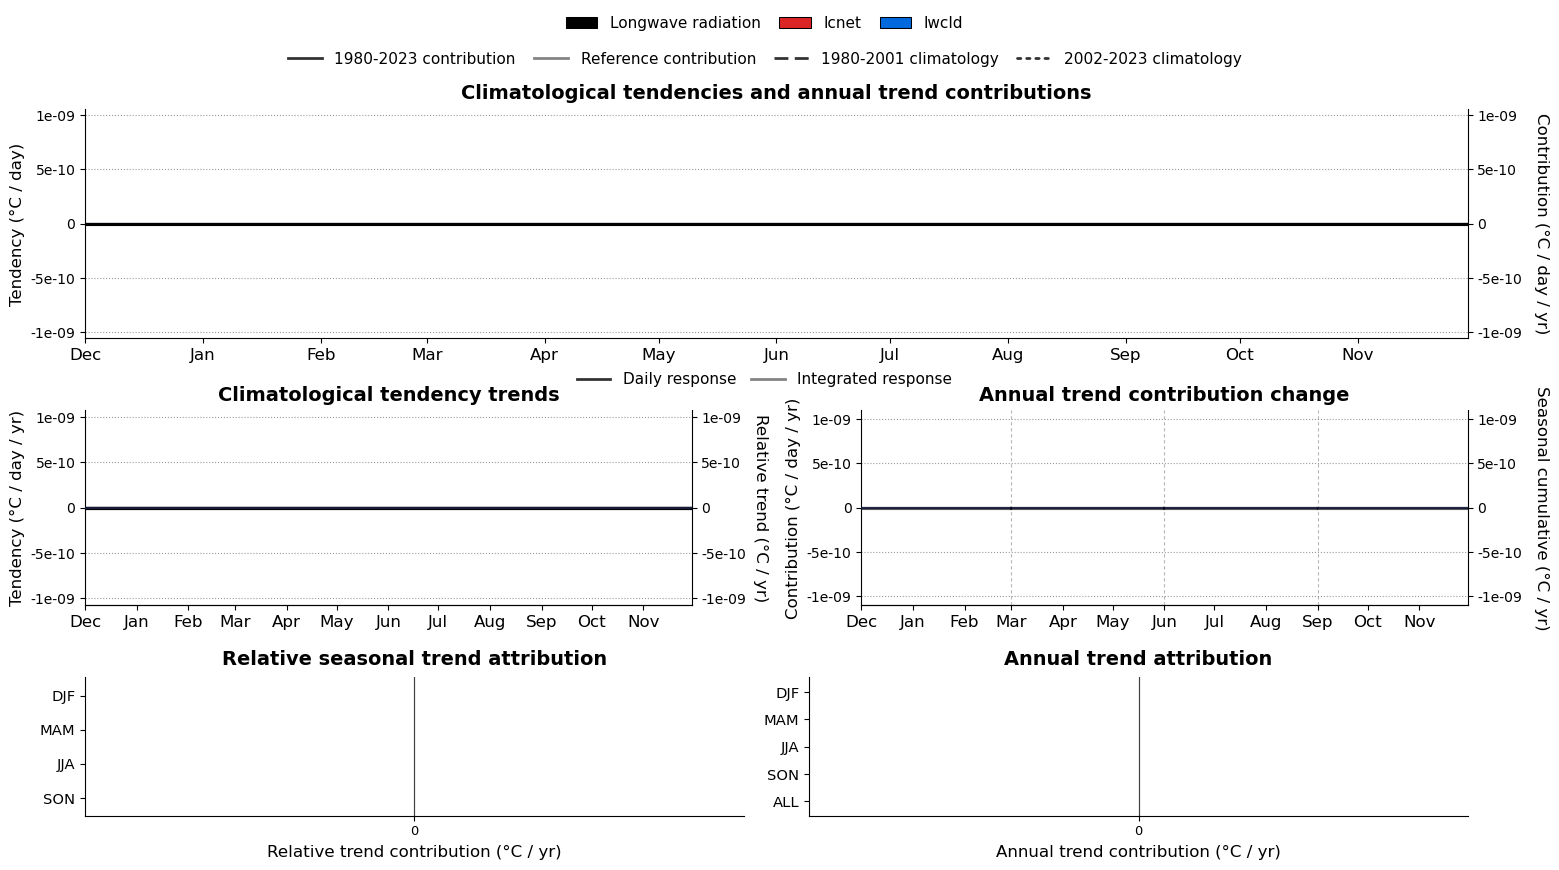

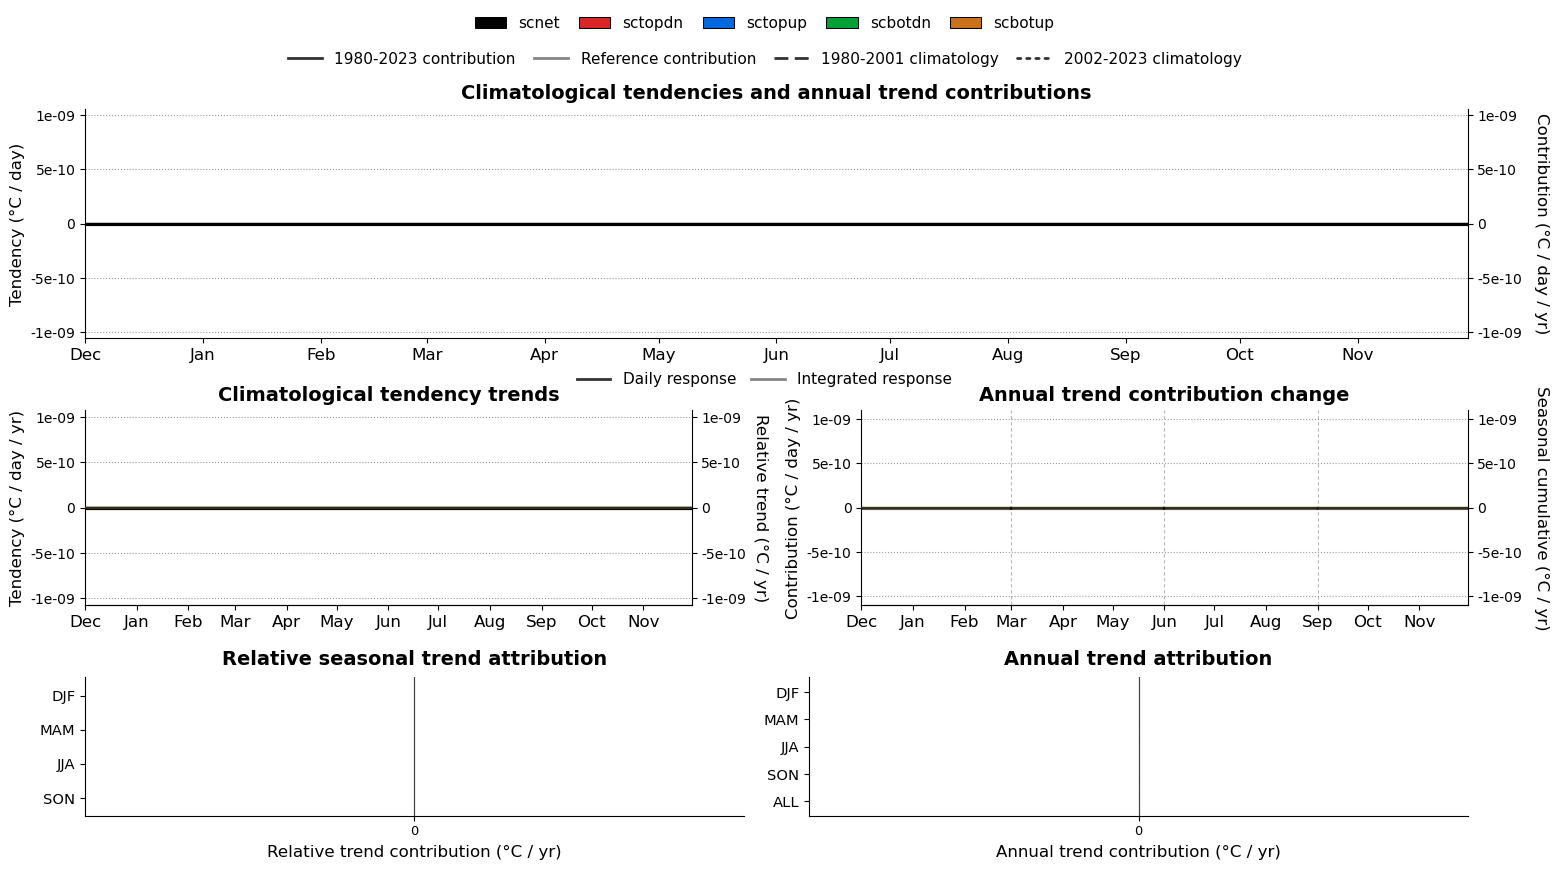

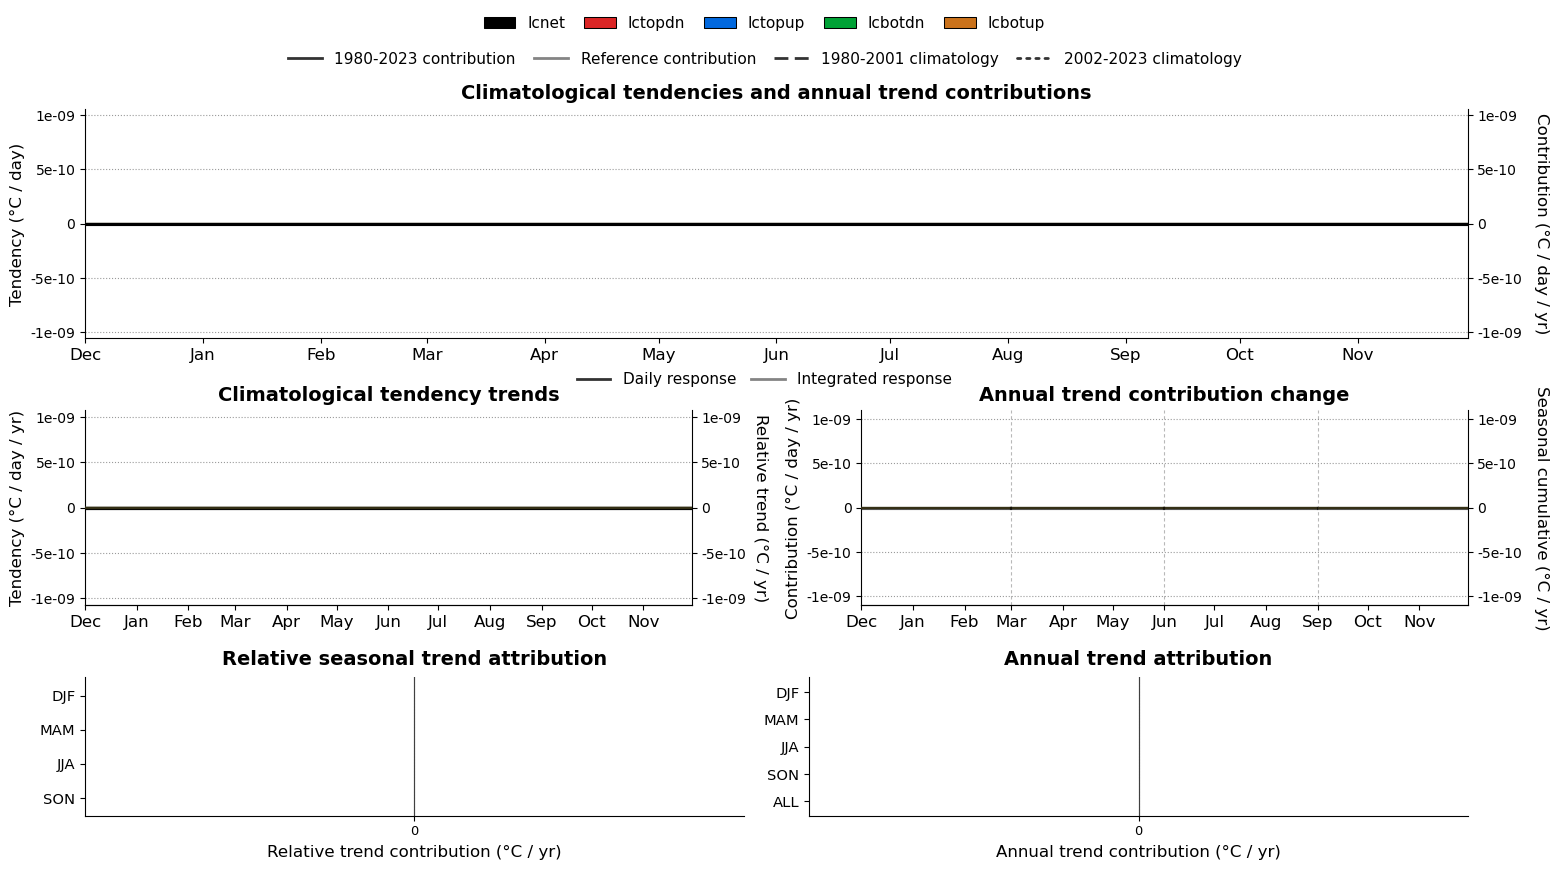

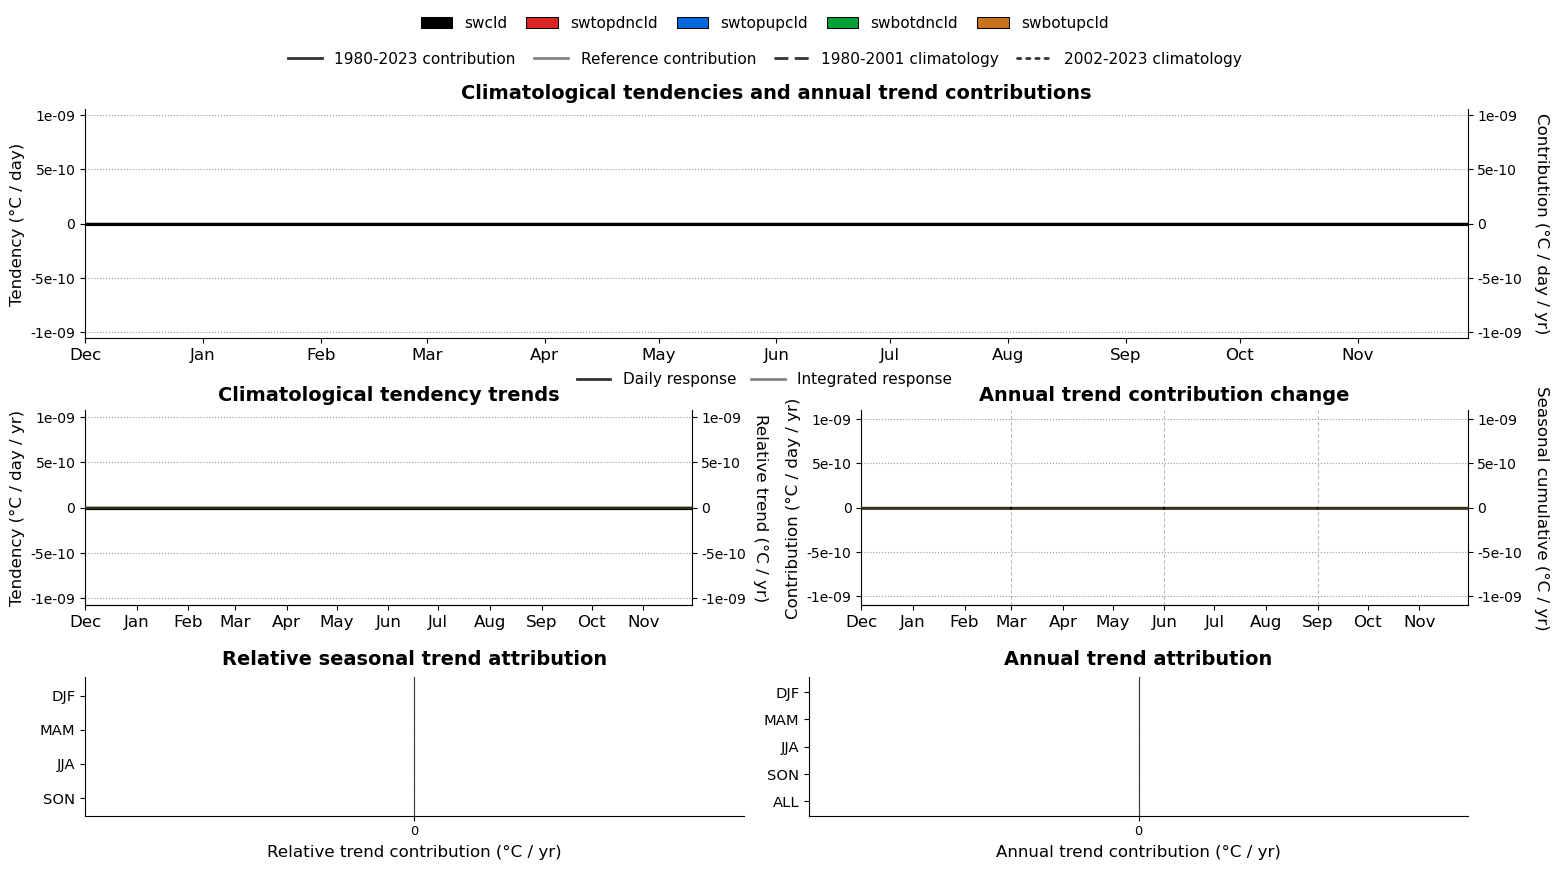

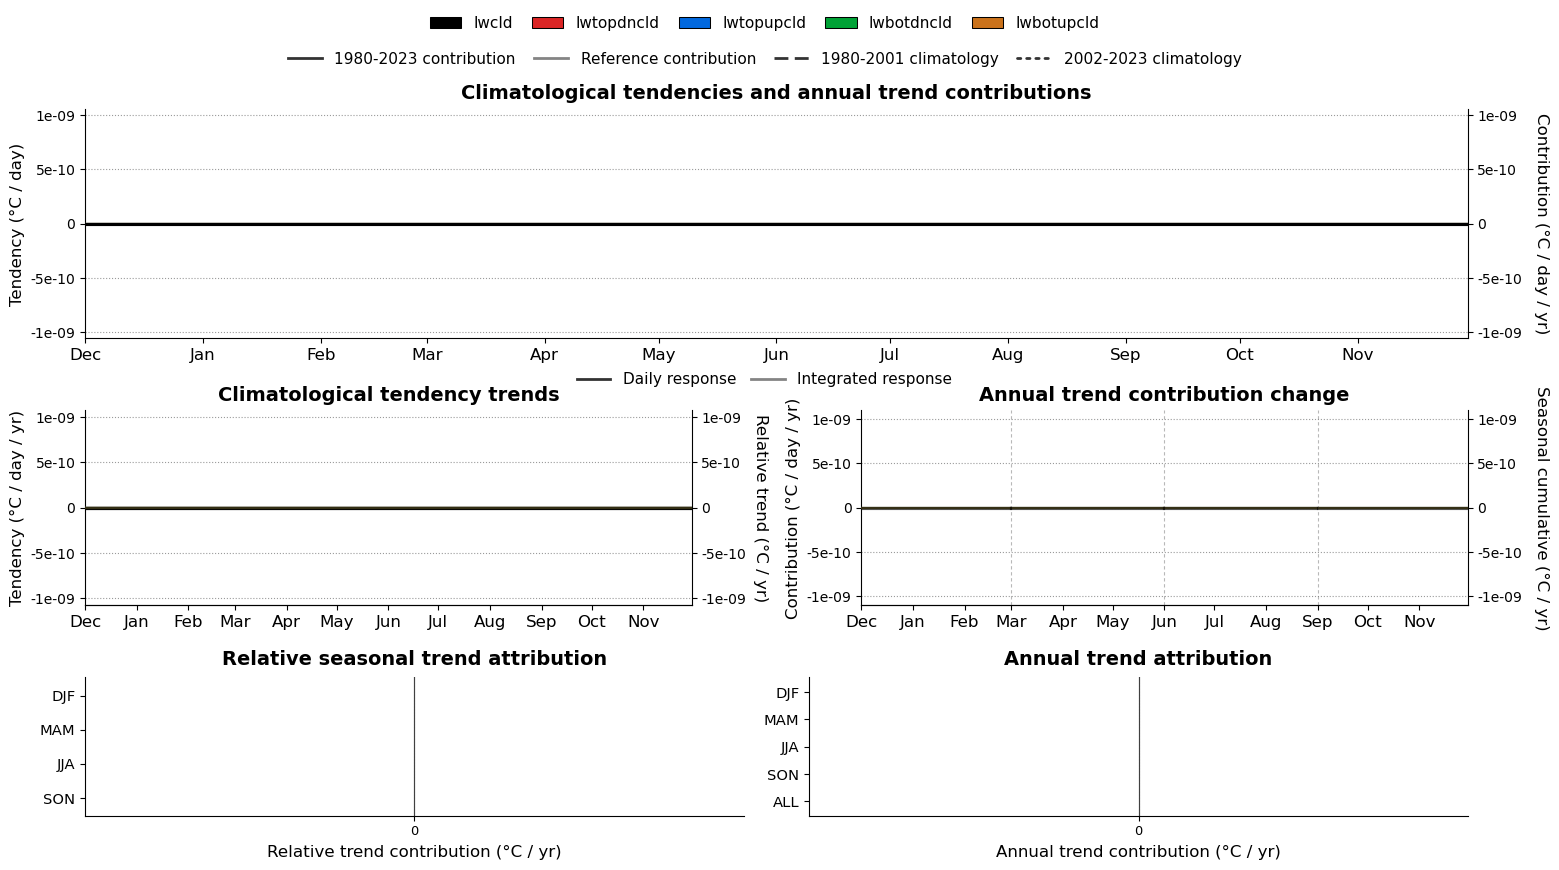

In [ ]:
# Process tendency diagnostics
process_period = 'Ptrend'
reference_label = 'Reference contribution' if reference_mode == 'stationary' else period_label(reference_period_key)
process_left, process_right = offset_periods[process_period]
shape_seasons = ['DJF', 'MAM', 'JJA', 'SON']
offset_seasons = ['DJF', 'MAM', 'JJA', 'SON', 'ALL']
annual_scale = 10.0
process_L = float(offset_L[process_period].item())
shape_to_year = 1.0 / process_L
separate_seasons = True
ylabel_fontsize = 12

total_scale_by_group = {
    'Total': 20.0,
}

process_label = {
    'tendtot': 'Total',
    'dyntot': 'Dynamics',
    'phystot': 'Physics',
    'numtot': 'Numerics',
    'radtot': 'Radiation',
    'swnet': 'Shortwave radiation',
    'lwnet': 'Longwave radiation',
    'senstot': 'Sensible heat',
    'frictot': 'Friction',
    'phasetot': 'Phase changes',
    'udtdx': 'Zonal advection',
    'vdtdy': 'Meridional advection',
    'adiadj': 'Adiabatic adjustment',
    'vertadv': 'Vertical advection',
}


def nice_step(target):
    if target <= 0.0 or not np.isfinite(target):
        return 1.0
    power = 10.0 ** np.floor(np.log10(target))
    for mult in [1.0, 2.0, 2.5, 5.0, 10.0]:
        step = mult * power
        if step >= target:
            return step
    return 10.0 * power


def clean_y_ticks(ax, nticks=6, min_ticks=4):
    ymin, ymax = ax.get_ylim()
    span = abs(ymax - ymin)
    step = nice_step(span / max(nticks - 1, 1))
    ticks = ticks_for_step((ymin, ymax), step)

    if len(ticks) < min_ticks:
        ticks = ticks_for_step((ymin, ymax), step / 2.0)

    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(FuncFormatter(compact_tick))


def season_slices(month_day_values):
    month = pd.Index(month_day_values.astype(str)).str.slice(0, 2).astype(int).to_numpy()
    season = np.empty(month.size, dtype='<U3')
    season[np.isin(month, [12, 1, 2])] = 'DJF'
    season[np.isin(month, [3, 4, 5])] = 'MAM'
    season[np.isin(month, [6, 7, 8])] = 'JJA'
    season[np.isin(month, [9, 10, 11])] = 'SON'
    breaks = np.r_[0, np.where(season[1:] != season[:-1])[0] + 1, len(season)]
    return [slice(int(breaks[i]), int(breaks[i + 1])) for i in range(len(breaks) - 1)]


def seasonal_cumsum_parts(da):
    return [da.isel(month_day=part).cumsum('month_day').astype('float32') for part in season_slices(da['month_day'].values)]


def draw_stacked_budget(ax, component_values, total_values, total_label_values, seasons, component_vars, colors, title, xlabel):
    y = np.arange(len(seasons), dtype=float)
    height = 0.34 if len(seasons) <= 1 else 0.22
    total_height = 0.18 if len(seasons) <= 1 else 0.14
    rows = []
    xmin = xmax = 0.0

    for season in seasons:
        pos_left = neg_left = 0.0
        bars = []
        for var in component_vars:
            value = float(component_values[var].sel(season=season))
            left = pos_left if value >= 0.0 else neg_left
            right = left + value
            bars.append((var, left, right, value))
            if value >= 0.0:
                pos_left = right
            else:
                neg_left = right

        total_value = float(total_values.sel(season=season))
        label_value = float(total_label_values.sel(season=season))
        xmin = min(xmin, neg_left, total_value)
        xmax = max(xmax, pos_left, total_value)
        rows.append((bars, total_value, label_value))

    span = max(xmax - xmin, 1e-12)
    pad = 0.08 * span
    xlim = (xmin - pad, xmax + pad)
    step = nice_step((xlim[1] - xlim[0]) / 9.0)
    ticks = ticks_for_step(xlim, step)
    if xlim[0] < 0 < xlim[1]:
        tick_list = list(ticks)
        if not any(tick < 0 for tick in tick_list):
            tick_list.insert(0, -step)
            xlim = (min(xlim[0], -1.12 * step), xlim[1])
        if not any(tick > 0 for tick in tick_list):
            tick_list.append(step)
            xlim = (xlim[0], max(xlim[1], 1.12 * step))
        ticks = np.asarray(sorted(set(np.round(tick_list, 10))), dtype=float)
    label_values = [label_value for _, _, label_value in rows if not np.isclose(label_value, 0.0)]
    labels_all_positive = bool(label_values) and all(value > 0.0 for value in label_values)

    for j, (bars, total_value, label_value) in enumerate(rows):
        for var, left, right, value in bars:
            if not np.isclose(value, 0.0):
                ax.barh(
                    y[j], abs(right - left), left=min(left, right), height=height,
                    color=colors[var], edgecolor='black', linewidth=0.55, zorder=3,
                )

        if not np.isclose(total_value, 0.0):
            y_total = y[j] - 0.5 * height - 0.075
            display_value = np.sign(total_value) * max(abs(total_value), 0.025 * (xlim[1] - xlim[0]))
            ax.barh(
                y_total, abs(display_value), left=min(0.0, display_value), height=total_height,
                color='black', edgecolor='black', linewidth=0.65, zorder=5,
            )
            label_offset = 0.014 * (xlim[1] - xlim[0])
            if labels_all_positive:
                label_x = display_value + label_offset
                ha = 'left'
            else:
                label_x = -np.sign(display_value) * label_offset
                ha = 'right' if display_value >= 0 else 'left'
            label_x = np.clip(label_x, xlim[0] + 0.02 * (xlim[1] - xlim[0]), xlim[1] - 0.02 * (xlim[1] - xlim[0]))
            label_y = y_total - 1.05 * total_height
            ax.text(
                label_x, label_y, f'{label_value:+.2f} °C/dec',
                ha=ha, va='center',
                color='black', fontsize=8.5, fontweight='bold', zorder=7,
            )

    ax.set_xlim(*xlim)
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(FuncFormatter(compact_tick))
    ax.set_yticks(y)
    ax.set_yticklabels(seasons)
    ax.set_ylim(y[-1] + 0.55, y[0] - 0.55)
    ax.axvline(0, color='0.25', lw=0.85, zorder=1)
    ax.grid(axis='x', linestyle=':', alpha=0.50)
    ax.set_axisbelow(True)
    ax.set_title(title, fontsize=14.0, pad=9, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12, labelpad=5)
    ax.tick_params(axis='x', labelsize=9.4)
    ax.tick_params(axis='y', labelsize=10.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


for group_name, leader_var in tends_main.items():
    if leader_var not in clim_tend:
        print(f'Skipping {group_name}: {leader_var} not found in clim_tend')
        continue

    component_vars = [var for var in tends_close.get(group_name, []) if var in clim_tend]
    missing_vars = [var for var in tends_close.get(group_name, []) if var not in clim_tend]
    if missing_vars:
        print(f'Skipping missing {group_name} components: {missing_vars}')

    plot_vars = [leader_var] + component_vars
    total_scale = float(total_scale_by_group.get(group_name, 1.0))
    total_note = f' x {compact_tick(total_scale)}' if not np.isclose(total_scale, 1.0) else ''

    colors = {leader_var: 'black'}
    component_palette = [c for c in COLORS if c not in ['#000000', 'black']]
    if len(component_palette) < len(component_vars):
        component_palette = list(plt.get_cmap('tab20').colors)
    for i, var in enumerate(component_vars):
        colors[var] = component_palette[i % len(component_palette)]

    def scaled(var, da):
        return (total_scale * da).astype('float32') if var == leader_var else da.astype('float32')

    clim_left = {var: clean_1d(clim_tend[var][process_left], 'month_day') for var in plot_vars}
    clim_right = {var: clean_1d(clim_tend[var][process_right], 'month_day') for var in plot_vars}
    delta_day = {
        var: (shape_to_year * clean_1d(shape_tend['day'][process_period][var]['deltaA'], 'month_day')).astype('float32')
        for var in plot_vars
    }
    shape_day = {
        var: (shape_to_year * clean_1d(shape_tend['day'][process_period][var]['Theta'], 'month_day')).astype('float32')
        for var in plot_vars
    }
    offset_day_ref = {
        var: clean_1d(ref_tendency(var, split='day'), 'month_day')
        for var in plot_vars
    }
    offset_day_trend = {
        var: clean_1d(annual_offset_tend['day'][process_period][var]['trend']['split'], 'month_day')
        for var in plot_vars
    }
    offset_day_change = {
        var: (offset_day_trend[var] - offset_day_ref[var]).astype('float32')
        for var in plot_vars
    }
    offset_day_cumsum = {
        var: seasonal_cumsum_parts(offset_day_change[var])
        for var in plot_vars
    }

    shape_season = {}
    offset_season_change = {}
    for var in plot_vars:
        shape_season[var] = clean_1d(
            shape_tend['season'][process_period][var]['Theta'],
            'season',
        ).sel(season=shape_seasons)

        ref_split = annual_scale * clean_1d(
            ref_tendency(var, split='season'),
            'season',
        ).sel(season=shape_seasons)
        trend_split = annual_scale * clean_1d(
            annual_offset_tend['season'][process_period][var]['trend']['split'],
            'season',
        ).sel(season=shape_seasons)

        ref_all = annual_scale * to_float(ref_tendency(var, split='season', total=True))
        trend_all = annual_scale * to_float(annual_offset_tend['season'][process_period][var]['trend']['total'])
        offset_season_change[var] = season_plus_all((trend_split - ref_split).astype('float32'), trend_all - ref_all)

    x = month_day_axis(clim_left[leader_var]['month_day'].values)
    month_ticks = month_tick_positions()

    clim_values = stack_values(
        scaled(var, da).values
        for var in plot_vars
        for da in [offset_day_trend[var], offset_day_ref[var], clim_left[var], clim_right[var]]
    )
    delta_values = stack_values(scaled(var, delta_day[var]).values for var in plot_vars)
    shape_values = stack_values(scaled(var, shape_day[var]).values for var in plot_vars)
    contribution_values = stack_values(scaled(var, offset_day_change[var]).values for var in plot_vars)
    cumsum_values = stack_values(scaled(var, part).values for var in plot_vars for part in offset_day_cumsum[var])

    fig = plt.figure(figsize=(15.8, 8.9))
    gs = fig.add_gridspec(
        3, 2,
        height_ratios=[1.35, 1.15, 0.82],
        hspace=0.38,
        wspace=0.28,
    )
    fig.subplots_adjust(top=0.875, left=0.070, right=0.945, bottom=0.080)

    ax_clim = fig.add_subplot(gs[0, :])
    ax_clim_contrib = ax_clim.twinx()
    ax_delta = fig.add_subplot(gs[1, 0])
    ax_shape = ax_delta.twinx()
    ax_contrib = fig.add_subplot(gs[1, 1], sharex=ax_delta)
    ax_cumsum = ax_contrib.twinx()

    bar_gs = gs[2, :].subgridspec(1, 2, wspace=0.10)
    ax_shape_bar = fig.add_subplot(bar_gs[0, 0])
    ax_offset_bar = fig.add_subplot(bar_gs[0, 1])

    for var in plot_vars:
        lw = 2.25 if var == leader_var else 1.55
        zorder = 5 if var == leader_var else 3

        ax_clim.plot(x, scaled(var, offset_day_trend[var]), color=colors[var], lw=lw, zorder=zorder)
        ax_clim.plot(x, scaled(var, offset_day_ref[var]), color=colors[var], lw=lw, alpha=0.42, zorder=zorder - 1)
        ax_clim.plot(x, scaled(var, clim_left[var]), color=colors[var], lw=0.90 * lw, ls='--', dashes=(5.0, 2.3), zorder=zorder)
        ax_clim.plot(x, scaled(var, clim_right[var]), color=colors[var], lw=0.90 * lw, ls=':', dashes=(1.2, 2.1), dash_capstyle='round', zorder=zorder)

        ax_delta.plot(x, scaled(var, delta_day[var]), color=colors[var], lw=lw, zorder=zorder)
        ax_shape.plot(x, scaled(var, shape_day[var]), color=colors[var], lw=lw, alpha=0.6, zorder=zorder)

        ax_contrib.plot(x, scaled(var, offset_day_change[var]), color=colors[var], lw=lw, zorder=zorder)
        for part in offset_day_cumsum[var]:
            ax_cumsum.plot(month_day_axis(part['month_day'].values), scaled(var, part), color=colors[var], lw=lw, alpha=0.6, zorder=zorder)

    style_calendar_axis(ax_clim, x, month_ticks, ylabel='Tendency (°C / day)', bottom=True, y_tick_labelsize=10)
    style_calendar_axis(ax_delta, x, month_ticks, ylabel='Tendency (°C / day / yr)', bottom=True, y_tick_labelsize=10)
    style_calendar_axis(ax_contrib, x, month_ticks, ylabel='Contribution (°C / day / yr)', bottom=True, y_tick_labelsize=10)
    style_twin_axis(ax_shape, ylabel='Relative trend (°C / yr)', labelpad=10, y_tick_labelsize=10)
    style_twin_axis(ax_cumsum, ylabel='Seasonal cumulative (°C / yr)', labelpad=14, y_tick_labelsize=10)
    for boundary in [x[part.start] for part in season_slices(clim_left[leader_var]['month_day'].values)[1:]]:
        ax_contrib.axvline(boundary, color='0.45', lw=0.8, ls='--', dashes=(3.0, 2.4), alpha=0.50, zorder=1)
    for ax in [ax_clim, ax_delta, ax_shape, ax_contrib, ax_cumsum]:
        ax.yaxis.label.set_size(ylabel_fontsize)

    ax_clim.set_ylim(*limits(clim_values, symmetric=True, pad=0.06))
    ax_delta.set_ylim(*limits(delta_values, symmetric=True, pad=0.08))
    ax_shape.set_ylim(*limits(shape_values, symmetric=True, pad=0.08))
    ax_contrib.set_ylim(*limits(contribution_values, symmetric=True, pad=0.10))
    ax_cumsum.set_ylim(*limits(cumsum_values, symmetric=True, pad=0.10))
    format_y_ticks(ax_clim, ax_delta, ax_shape, ax_contrib, ax_cumsum)
    for ax in [ax_clim, ax_delta, ax_shape, ax_contrib, ax_cumsum]:
        clean_y_ticks(ax)
    ax_clim_contrib.set_ylim(ax_clim.get_ylim())
    ax_clim_contrib.set_yticks(ax_clim.get_yticks())
    ax_clim_contrib.set_ylabel('Contribution (°C / day / yr)', rotation=270, labelpad=14, va='center')
    ax_clim_contrib.yaxis.set_major_formatter(FuncFormatter(compact_tick))
    ax_clim_contrib.tick_params(axis='y', right=True, labelright=True, labelsize=10)
    ax_clim_contrib.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_clim_contrib.spines['right'].set_visible(True)
    ax_clim_contrib.spines['top'].set_visible(False)
    ax_clim_contrib.spines['left'].set_visible(False)
    ax_clim_contrib.spines['bottom'].set_visible(False)
    ax_clim_contrib.yaxis.label.set_size(ylabel_fontsize)

    ax_clim.set_title(f'Climatological tendencies and annual trend contributions', fontsize=14, pad=7, fontweight='bold')
    ax_delta.set_title('Climatological tendency trends', fontsize=14.0, pad=7, fontweight='bold')
    ax_contrib.set_title('Annual trend contribution change', fontsize=14.0, pad=7, fontweight='bold')

    if separate_seasons:
        shape_bar_seasons = shape_seasons
        offset_bar_seasons = offset_seasons
        shape_components = {var: shape_to_year * shape_season[var] for var in component_vars}
        shape_total = total_scale * shape_to_year * shape_season[leader_var]
        shape_total_label = (annual_scale * shape_to_year * shape_season[leader_var]).astype('float32')
        offset_components = {var: offset_season_change[var] / annual_scale for var in component_vars}
        offset_total = total_scale * offset_season_change[leader_var] / annual_scale
        offset_total_label = offset_season_change[leader_var].astype('float32')
        shape_bar_title = 'Relative seasonal trend attribution'
        offset_bar_title = 'Annual trend attribution'
    else:
        shape_bar_seasons = ['ALL']
        offset_bar_seasons = ['ALL']
        shape_components = {
            var: xr.DataArray(
                [float((shape_to_year * shape_season[var]).sum('season'))],
                dims='season', coords={'season': ['ALL']},
            )
            for var in component_vars
        }
        shape_total = xr.DataArray(
            [float((total_scale * shape_to_year * shape_season[leader_var]).sum('season'))],
            dims='season', coords={'season': ['ALL']},
        )
        shape_total_label = xr.DataArray(
            [float((annual_scale * shape_to_year * shape_season[leader_var]).sum('season'))],
            dims='season', coords={'season': ['ALL']},
        )
        offset_components = {
            var: (offset_season_change[var] / annual_scale).sel(season=['ALL'])
            for var in component_vars
        }
        offset_total = (total_scale * offset_season_change[leader_var] / annual_scale).sel(season=['ALL'])
        offset_total_label = offset_season_change[leader_var].sel(season=['ALL']).astype('float32')
        shape_bar_title = 'Net relative trend contribution'
        offset_bar_title = 'Net annual trend contribution'

    draw_stacked_budget(
        ax_shape_bar,
        shape_components,
        shape_total,
        shape_total_label,
        shape_bar_seasons,
        component_vars,
        colors,
        shape_bar_title,
        'Relative trend contribution (°C / yr)',
    )
    draw_stacked_budget(
        ax_offset_bar,
        offset_components,
        offset_total,
        offset_total_label,
        offset_bar_seasons,
        component_vars,
        colors,
        offset_bar_title,
        'Annual trend contribution (°C / yr)',
    )

    process_handles = [
        Patch(facecolor='black', edgecolor='black', linewidth=0.75, label=f'{process_label.get(leader_var, leader_var)}{total_note}'),
    ] + [
        Patch(facecolor=colors[var], edgecolor='black', linewidth=0.75, label=process_label.get(var, var))
        for var in component_vars
    ]
    clim_style_handles = [
        Line2D([0], [0], color='0.20', lw=2.0, label=f'{period_label(process_period)} contribution'),
        Line2D([0], [0], color='0.20', lw=2.0, alpha=0.6, label=reference_label),
        Line2D([0], [0], color='0.20', lw=2.0, ls='--', dashes=(5.0, 2.3), label=f'{period_label(process_left)} climatology'),
        Line2D([0], [0], color='0.20', lw=2.0, ls=':', dashes=(1.2, 2.1), dash_capstyle='round', label=f'{period_label(process_right)} climatology'),
    ]
    change_style_handles = [
        Line2D([0], [0], color='0.20', lw=2.0, label='Daily response'),
        Line2D([0], [0], color='0.20', lw=2.0, alpha=0.60, label='Integrated response'),
    ]

    fig.legend(
        handles=process_handles,
        loc='upper center', bbox_to_anchor=(0.5, 0.995),
        ncol=min(len(process_handles), 6), frameon=False,
        columnspacing=1.25, handlelength=2.05, fontsize=11.0,
    )
    fig.legend(
        handles=clim_style_handles,
        loc='upper center', bbox_to_anchor=(0.5, 0.955),
        ncol=len(clim_style_handles), frameon=False,
        columnspacing=1.20, handlelength=2.25, fontsize=11.0,
    )
    fig.legend(
        handles=change_style_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, max(ax_delta.get_position().y1, ax_contrib.get_position().y1) + 0.058),
        ncol=len(change_style_handles), frameon=False,
        columnspacing=1.0, handlelength=2.20, fontsize=11.0,
    )

    plt.show()

Plotje van Surface temperature - templ1
Windrozen van Frank van de twee periodes. Per seizoen
Sensible heat ook ontbinden